# Pipeline de Análise Industrial - África e Médio Oriente

## Passos 1 a 10 com Geração Automática de Metadados

Este notebook executa o fluxo completo de análise de dados para 37 países da África e Médio Oriente, utilizando dados do Banco Mundial (WDI + WGI).

**Características:**
- Clonagem automática do repositório GitHub
- Extração automática via API (WDI + WGI)
- Agregação INNER JOIN + Dados Sintéticos (500 anos)
- Engenharia de Features avançada (lags, MA, deltas, interações)
- 7 Modelos (5 Clássicos + 2 Bayesianos)
- Interpretabilidade SHAP + Análise Geográfica
- **Sincronização simultânea de TODOS os ficheiros no Google Drive**
- **Visualização inline de TODAS as imagens geradas em cada passo**

## 0. Configuração Inicial do Colab

In [1]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive montado em /content/drive")

Mounted at /content/drive
✓ Google Drive montado em /content/drive


In [2]:
# Instalar dependências
!pip install -q wbgapi pmdarima xgboost shap geopandas pymc arviz tensorflow scipy
print("✓ Dependências instaladas")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.5 MB/s eta 0:00:00
✓ Dependências instaladas


In [3]:
# Clonar repositório GitHub
!git clone https://github.com/ottrindade1963/analise-industrialXL.git /content/repo
print("✓ Repositório clonado do GitHub")

Cloning into '/content/repo'...
remote: Enumerating objects: 198, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 198 (delta 60), reused 11 (delta 11), pack-reused 109 (from 1)
Receiving objects: 100% (198/198), 22.04 MiB | 15.44 MiB/s, done.
Resolving deltas: 100% (92/92), done.
✓ Repositório clonado do GitHub


In [4]:
import os
import sys
import time
import shutil
import glob
from datetime import datetime
from pathlib import Path
from IPython.display import display, Image, HTML

# Configurar paths
REPO_DIR = '/content/repo'  # Repositório clonado do GitHub
PIPELINE_DIR = os.path.join(REPO_DIR, 'pipeline_africa_mo')  # Subdiretório do pipeline
DRIVE_DIR = '/content/drive/MyDrive/pipeline_africa_mo_resultados'  # Resultados no Drive

# Verificar se o pipeline está no subdiretório ou na raiz
if not os.path.exists(PIPELINE_DIR):
    PIPELINE_DIR = REPO_DIR  # Se estiver na raiz

os.chdir(PIPELINE_DIR)
sys.path.insert(0, PIPELINE_DIR)

# Criar diretório de resultados no Drive
os.makedirs(DRIVE_DIR, exist_ok=True)

print(f"✓ Diretório de trabalho: {PIPELINE_DIR}")
print(f"✓ Diretório de resultados (Drive): {DRIVE_DIR}")
print(f"\n  Ficheiros do pipeline:")
for f in sorted(os.listdir(PIPELINE_DIR)):
    if f.endswith('.py') or f.endswith('.md'):
        print(f"    {f}")

✓ Diretório de trabalho: /content/repo
✓ Diretório de resultados (Drive): /content/drive/MyDrive/pipeline_africa_mo_resultados

  Ficheiros do pipeline:
    Pipeline_Africa_MO_Completo.py
    README.md
    colab_init_complete.py
    config_global.py
    metadata_generator.py
    passo10_inovacoes_mestrado.py
    passo1_extracao.py
    passo2_1_limpeza.py
    passo2_2_agregacao_sinteticos.py
    passo2_3_eda_agregados.py
    passo2_eda_brutos.py
    passo3_engenharia_features.py
    passo4_treino_modelos.py
    passo5_avaliacao.py
    passo6_estrategias.py
    passo7_shap.py
    passo8_geografica.py
    passo9_avancada.py
    visualizar_imagens.py


In [5]:
# Função auxiliar para sincronizar TODOS os ficheiros gerados com o Drive
def sincronizar_todos_drive():
    """
    Sincroniza TODOS os diretórios de resultados com o Google Drive.
    Chamada após cada passo para backup simultâneo.
    """
    diretorio_saida = [
        'dados_brutos',
        'dados_limpos',
        'dados_agregados',
        'dados_sinteticos',
        'dados_engenharia',
        'eda_brutos',
        'eda_agregados',
        'eda_engenharia',
        'modelos_treinados',
        'resultados_avaliacao',
        'analise_estrategias',
        'shap_analysis',
        'analise_geografica',
        'analise_avancada',
        'metadados'
    ]

    ficheiros_sincronizados = 0

    for dir_name in diretorio_saida:
        origem = os.path.join(PIPELINE_DIR, dir_name)
        if not os.path.exists(origem):
            continue

        destino = os.path.join(DRIVE_DIR, dir_name)
        os.makedirs(destino, exist_ok=True)

        # Sincronizar ficheiros (incluindo subdirectórios)
        for root, dirs, files in os.walk(origem):
            rel_path = os.path.relpath(root, origem)
            dest_root = os.path.join(destino, rel_path) if rel_path != '.' else destino
            os.makedirs(dest_root, exist_ok=True)
            for f in files:
                src = os.path.join(root, f)
                dst = os.path.join(dest_root, f)
                shutil.copy2(src, dst)
                ficheiros_sincronizados += 1

    return ficheiros_sincronizados


def mostrar_imagens(diretorios, titulo=None):
    """
    Mostra inline TODAS as imagens PNG encontradas nos directórios especificados.
    Pesquisa recursivamente em subdirectórios.

    Args:
        diretorios: lista de caminhos absolutos ou relativos a PIPELINE_DIR
        titulo: título opcional para o bloco de imagens
    """
    imagens = []
    for d in diretorios:
        # Resolver caminho absoluto
        if not os.path.isabs(d):
            d = os.path.join(PIPELINE_DIR, d)
        if not os.path.exists(d):
            continue
        # Buscar PNGs recursivamente
        for root, dirs, files in os.walk(d):
            for f in sorted(files):
                if f.lower().endswith('.png'):
                    imagens.append(os.path.join(root, f))

    if not imagens:
        print("  (Nenhuma imagem gerada neste passo)")
        return

    if titulo:
        display(HTML(f'<h3>📊 {titulo} ({len(imagens)} imagens)</h3>'))
    else:
        display(HTML(f'<h3>📊 Visualizações geradas ({len(imagens)} imagens)</h3>'))

    for img_path in imagens:
        # Mostrar nome do ficheiro como legenda
        nome_ficheiro = os.path.basename(img_path)
        subdir = os.path.basename(os.path.dirname(img_path))
        display(HTML(f'<hr><b>{subdir}/{nome_ficheiro}</b>'))
        display(Image(filename=img_path, width=900))

    print(f"\n  ✓ {len(imagens)} imagens visualizadas")


print("✓ Funções auxiliares definidas (sincronização + visualização de imagens)")

✓ Funções auxiliares definidas (sincronização + visualização de imagens)


---
## 1. Extração de Dados (WDI + WGI)

In [6]:
print("\n" + "="*70)
print("  PASSO 1: EXTRAÇÃO DE DADOS VIA API")
print("="*70)

t0 = time.time()
from passo1_extracao import executar_passo1
executar_passo1()

tempo_p1 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p1:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")
# Passo 1 não gera imagens (apenas CSVs de dados brutos)


  PASSO 1: EXTRAÇÃO DE DADOS VIA API

  PASSO 1: EXTRAÇÃO DE DADOS - INÍCIO
PASSO 1.1: Extração de dados WDI
  Países: 37
  Indicadores: 19
  Período: 1996-2023
  Extraindo: valor_agregado_industrial_percent_pib (NV.IND.TOTL.ZS)...
    ✓ 1036 registos
  Extraindo: pib_per_capita_ppc (NY.GDP.PCAP.PP.KD)...
    ✓ 1036 registos
  Extraindo: crescimento_pib_anual (NY.GDP.MKTP.KD.ZG)...
    ✓ 1036 registos
  Extraindo: formacao_bruta_capital_fixo_percent_pib (NE.GDI.FTOT.ZS)...
    ✓ 1036 registos
  Extraindo: ied_percent_pib (BX.KLT.DINV.WD.GD.ZS)...
    ✓ 1036 registos
  Extraindo: comercio_percent_pib (NE.TRD.GNFS.ZS)...
    ✓ 1036 registos
  Extraindo: exportacoes_percent_pib (NE.EXP.GNFS.ZS)...
    ✓ 1036 registos
  Extraindo: importacoes_percent_pib (NE.IMP.GNFS.ZS)...
    ✓ 1036 registos
  Extraindo: consumo_eletricidade_per_capita (EG.USE.ELEC.KH.PC)...
    ✓ 1036 registos
  Extraindo: utilizadores_internet_percent (IT.NET.USER.ZS)...
    ✓ 1036 registos
  Extraindo: despesa_id_per

---
## 2. EDA dos Dados Brutos

In [7]:
print("\n" + "="*70)
print("  PASSO 2: EDA DOS DADOS BRUTOS")
print("="*70)

t0 = time.time()
from passo2_eda_brutos import executar_passo2
executar_passo2()

tempo_p2 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p2:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 2: EDA DOS DADOS BRUTOS

PASSO 2: ANÁLISE EXPLORATÓRIA DOS DADOS BRUTOS

  === EDA: WDI ===
  Shape: (1036, 22)
  Países: 37
  Anos: 1996-2023

  === EDA: WGI ===
  Shape: (925, 9)
  Países: 37
  Anos: 1996-2023
[METADADOS] passo2_eda_brutos → /content/repo/metadados/passo2_eda_brutos_metadata.json
[AUTO-SAVE] 9 ficheiros copiados para Google Drive

  ✓ PASSO 2 CONCLUÍDO

  ⏱ Tempo: 7.6s
  📁 13 ficheiros sincronizados com o Drive


In [ ]:
# Visualizar imagens geradas no Passo 2
mostrar_imagens(['eda_brutos'], titulo='Passo 2 - EDA Dados Brutos')

---
## 2.1. Limpeza de Dados

In [8]:
print("\n" + "="*70)
print("  PASSO 2.1: LIMPEZA DE DADOS")
print("="*70)

t0 = time.time()
from passo2_1_limpeza import executar_passo2_1
executar_passo2_1()

tempo_p2_1 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p2_1:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 2.1: LIMPEZA DE DADOS

PASSO 2.1: LIMPEZA E EDA - MICE SEM WINSORIZAÇÃO

  WDI bruto: (1036, 22)
  WGI bruto: (925, 9)

  === LIMPEZA WDI (Quantitativo - MICE) ===
  Shape original: (1036, 22)
  Missing: 2348 valores

  [1] MICE (IterativeImputer) por país...
      Variáveis numéricas: 19
      max_iter=20, random_state=42
      Valores imputados por MICE: 1824
      Missing residuais após MICE: 524

  [2] Preenchimento de NaN residuais (mediana por país)...

  [✓] Winsorização NÃO aplicada (preserva eventos extremos reais)
      Justificação: outliers em economias emergentes representam
      eventos reais (crises, recuperações pós-conflito).
      Modelos de árvores (RF, XGBoost) são robustos a outliers.

  Shape final: (1036, 22)
  Missing residuais: 0

  === LIMPEZA WGI (Qualitativo - Governança - MICE) ===
  Shape original: (925, 9)
  Missing: 0 valores

  [✓] Sem valores faltantes - nenhuma imputação necessária
  [✓] Escala WGI original preservada (-2.5 a +2.5)

  Shape 

In [ ]:
# Visualizar imagens geradas no Passo 2.1 (EDA WDI + WGI limpos)
mostrar_imagens(
    [os.path.join('dados_limpos', 'eda_wdi'), os.path.join('dados_limpos', 'eda_wgi')],
    titulo='Passo 2.1 - EDA após Limpeza (WDI + WGI)'
)

---
## 2.2. Agregação INNER JOIN + Dados Sintéticos

In [9]:
print("\n" + "="*70)
print("  PASSO 2.2: AGREGAÇÃO INNER JOIN + DADOS SINTÉTICOS (500 ANOS)")
print("="*70)

t0 = time.time()
from passo2_2_agregacao_sinteticos import executar_passo2_2
executar_passo2_2()

tempo_p2_2 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p2_2:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")
# Passo 2.2 não gera imagens (apenas CSVs de dados agregados e sintéticos)


  PASSO 2.2: AGREGAÇÃO INNER JOIN + DADOS SINTÉTICOS (500 ANOS)

PASSO 2.2: AGREGAÇÃO INNER JOIN + DADOS SINTÉTICOS

  === Agregação: INNER JOIN ===
  WDI: (1036, 22)
  WGI: (925, 9)
  Resultado INNER JOIN: (925, 28)
  Países no resultado: 37
  Anos: 1996-2023
  ✓ Integridade verificada: 925 registos únicos

  ✓ Agregado salvo: /content/repo/dados_agregados/agregado_inner_join.csv

  === Geração de Dados Sintéticos (500 anos) ===
    Processando país 10/37: ETH
    Processando país 20/37: MAR
    Processando país 30/37: SEN
  Dataset sintético: (18500, 28)
  Países: 37
  Anos: 2024-2523
  ✓ Sintético salvo: /content/repo/dados_sinteticos/sintetico_500anos.csv
  ✓ Combinado salvo: /content/repo/dados_sinteticos/combinado_real_sintetico.csv

  === Geração de WDI Sintético (500 anos, sem WGI) ===

  === Geração de Dados Sintéticos (500 anos) ===
    Processando país 10/37: ETH
    Processando país 20/37: MAR
    Processando país 30/37: SEN
  Dataset sintético: (18500, 22)
  Países: 37
  

---
## 2.3. EDA Agregados + Sintéticos

In [10]:
print("\n" + "="*70)
print("  PASSO 2.3: EDA AGREGADOS + SINTÉTICOS")
print("="*70)

t0 = time.time()
from passo2_3_eda_agregados import executar_passo2_3
executar_passo2_3()

tempo_p2_3 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p2_3:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 2.3: EDA AGREGADOS + SINTÉTICOS

PASSO 2.3: EDA AGREGADOS + SINTÉTICOS

  === EDA: agregado_real ===

  === EDA: sintetico_500 ===
[METADADOS] passo2_3_eda_agregados → /content/repo/metadados/passo2_3_eda_agregados_metadata.json
[AUTO-SAVE] 11 ficheiros copiados para Google Drive

  ✓ PASSO 2.3 CONCLUÍDO

  ⏱ Tempo: 19.0s
  📁 40 ficheiros sincronizados com o Drive


In [ ]:
# Visualizar imagens geradas no Passo 2.3
mostrar_imagens(['eda_agregados'], titulo='Passo 2.3 - EDA Agregados e Sintéticos')

---
## 3. Engenharia de Features

In [11]:
print("\n" + "="*70)
print("  PASSO 3: ENGENHARIA DE FEATURES AVANÇADA")
print("="*70)

t0 = time.time()
from passo3_engenharia_features import executar_passo3
executar_passo3()

tempo_p3 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p3:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")



  PASSO 3: ENGENHARIA DE FEATURES AVANÇADA

PASSO 3: ENGENHARIA DE FEATURES - ESTRATÉGIA PARCIMONIOSA (A2)
  Princípios: PCA train-only | Lags max=2 | WGI removidos | Ratio >3

----------------------------------------------------------------------
DATASET 1: WDI LIMPO (SEM WGI)
----------------------------------------------------------------------

  === Engenharia de Features (Parcimoniosa): wdi_limpo ===
  Shape original: (1036, 22)

  [PCA] Estratégia A2 - Fator Latente (train-only)...
    (Sem variáveis WGI - PCA não aplicável a este dataset)
  [2] Lags quantitativos (1): 16 features
  [3] Lags target (1,2): 2 features
  [6] Log-retornos: 4 features
  [ANTECEDÊNCIA] Removidas 18 variáveis contemporâneas (mantidos apenas lags e derivadas)
    Removidas: ['pib_per_capita_ppc', 'crescimento_pib_anual', 'formacao_bruta_capital_fixo_percent_pib', 'ied_percent_pib', 'comercio_percent_pib', 'exportacoes_percent_pib', 'importacoes_percent_pib', 'consumo_eletricidade_per_capita', 'utilizad

In [ ]:
# Visualizar imagens geradas no Passo 3 (PCA e análise de features)
mostrar_imagens(['eda_engenharia'], titulo='Passo 3 - Engenharia de Features (PCA e Análise)')

---
## 4. Treinamento de 7 Modelos

In [12]:
print("\n" + "="*70)
print("  PASSO 4: TREINAMENTO DE 7 MODELOS")
print("  (5 Clássicos: RF, XGBoost, GradientBoosting, SARIMAX, LSTM)")
print("  (2 Bayesianos: PartialPooling, CompletePooling)")
print("="*70)

t0 = time.time()
from passo4_treino_modelos import executar_passo4
executar_passo4()

tempo_p4 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p4:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")
# Passo 4 não gera imagens (apenas modelos .pkl e metadados)


  PASSO 4: TREINAMENTO DE 7 MODELOS
  (5 Clássicos: RF, XGBoost, GradientBoosting, SARIMAX, LSTM)
  (2 Bayesianos: PartialPooling, CompletePooling)

  PASSO 4: TREINO COM VALIDAÇÃO WALK-FORWARD TEMPORAL
  Walk-forward: 5 folds (expanding window)
  Modelo final: split 85/15 temporal
  Regularização: forte (L1+L2) para parcimónia com ~25 anos

  MODELOS PCA (do Passo 3): /content/repo/dados_engenharia/pca_models
    ✓ agregado: PCA(3 comp, 94.8% var) + StandardScaler(6 features)
      WGI inputs: ['wgi_controle_corrupcao', 'wgi_eficacia_governo', 'wgi_estabilidade_politica', 'wgi_qualidade_regulatoria', 'wgi_estado_direito', 'wgi_voz_responsabilizacao']
    ✓ sintetico: PCA(3 comp, 92.4% var) + StandardScaler(6 features)
      WGI inputs: ['wgi_controle_corrupcao', 'wgi_eficacia_governo', 'wgi_estabilidade_politica', 'wgi_qualidade_regulatoria', 'wgi_estado_direito', 'wgi_voz_responsabilizacao']

  WDI_Limpo: (962, 26)

  Agregado: (888, 34)
    PCA features (8): ['wgi_pca1_lag1', 'wgi_

---
## 5. Avaliação de Performance

In [13]:
print("\n" + "="*70)
print("  PASSO 5: AVALIAÇÃO DE PERFORMANCE")
print("="*70)

t0 = time.time()
from passo5_avaliacao import executar_passo5
executar_passo5()

tempo_p5 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p5:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 5: AVALIAÇÃO DE PERFORMANCE

  PASSO 5: AVALIACAO DE PERFORMANCE - 28 MODELOS + BASELINES

  [1/9] Carregando modelos e avaliando em dados de teste...
    Modelos avaliados: 28

  [2/9] Avaliando baselines ingenuas (Persistencia, Media Movel, Drift)...
    Melhor modelo RMSE: 2.8913
    Melhor baseline RMSE: 8.6919
    Ganho vs baseline: 66.7%
    Modelos com MASE < 1 (melhor que naive): 21/28

  [3/9] Tabela resumo por modelo (media dos 4 datasets)...
    Melhor modelo: Bayes_PartialPooling (RMSE=3.2080)

  [4/9] Teste Diebold-Mariano (WDI_Limpo vs Agregado)...
    RandomForest: DM=0.030, p=0.9764, Ganho=0.4%
    XGBoost: DM=-0.057, p=0.9543, Ganho=-0.8%
    GradientBoosting: DM=-0.565, p=0.5728, Ganho=-8.3%
    SARIMAX: DM=-0.233, p=0.8158, Ganho=-4.6%
    LSTM: DM=-0.344, p=0.7312, Ganho=-4.9%
    Bayes_PartialPooling: DM=-0.089, p=0.9290, Ganho=-1.7%
    Bayes_CompletePooling: DM=-0.326, p=0.7451, Ganho=-6.9%
    Significativos (p<0.05): 0/7

  [5/9] IC 95% via bootstrap (

In [ ]:
# Visualizar imagens geradas no Passo 5
mostrar_imagens(['resultados_avaliacao'], titulo='Passo 5 - Avaliação de Performance')

### **SEGUNDA PARTE (OS FICHEIROS TEMPORÁRIOS PRECISAM SER RESTURADOS**

**Instalando dependência**

In [ ]:
#!pip install gdown -q
#!pip install ruptures


**RESTAURAR FICHEIROS DO DRIVE**

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

#import urllib.request

#url = 'https://raw.githubusercontent.com/ottrindade1963/analise-industrialXL/main/colab_auto_sync_github.py'

#exec(urllib.request.urlopen(url ).read())


**VERIFICAÇÃO E ORDENAÇÃO DOS CAMINHO PARA O PASSO6**

In [65]:
import os
import sys

# Corrigir caminhos para o Colab
sys.path.insert(0, '/content/repo/pipeline_africa_mo')
import config_global as config

# Sobrescrever caminhos
config.DADOS_ENGENHARIA_DIR = '/content/repo/pipeline_africa_mo/dados_engenharia'
config.MODELOS_DIR = '/content/repo/pipeline_africa_mo/modelos'
config.ESTRATEGIAS_DIR = '/content/repo/pipeline_africa_mo/analise_estrategias'

# Verificar
print("Caminhos corrigidos:")
print(f"  Dados: {config.DADOS_ENGENHARIA_DIR}")
print(f"  Modelos: {config.MODELOS_DIR}")

# Agora execute o passo 6
from passo6_estrategias import executar_passo6
executar_passo6()


Caminhos corrigidos:
  Dados: /content/repo/pipeline_africa_mo/dados_engenharia
  Modelos: /content/repo/pipeline_africa_mo/modelos

  PASSO 6: ANALISE DE ESTRATEGIAS E MODERACAO

  [1/7] Carregando dados...
    Dataset: (925, 28)
    WGI: 6 variaveis
    WDI: 12 variaveis

  [2/7] Correlacoes WGI x Target...
    Correlacoes significativas: 5/6

  [3/7] Efeitos de moderacao (interacoes WGI x WDI com OLS)...
    Interacoes testadas: 12
    Significativas (p<0.05): 6
    Melhor: wgi_controle_corrupcao x pib_per_capita_ppc (beta=-0.000, p=0.0000)

  [4/7] Clusters de governanca (K-Means)...
    Clusters: {'Governanca_Media': 16, 'Governanca_Baixa': 11, 'Governanca_Alta': 10}

  [5/7] Performance dos modelos por cluster...

  [6/7] Impacto WGI por pais...
    Paises analisados: 37

  [7/7] Gerando visualizacoes...
    heatmap_correlacoes_wgi_wdi.png
    scatter_moderacao_top4.png
    clusters_governanca_pca.png
    impacto_wgi_por_pais_top_bottom.png
    scatter_wgi_vs_target.png
[METADADO

---
## 6. Análise de Estratégias

In [66]:
import time
import os
import sys

print("\n" + "="*70)
print("  PASSO 6: ANÁLISE DE ESTRATÉGIAS")
print("="*70)

t0 = time.time()
from passo6_estrategias import executar_passo6
executar_passo6()

tempo_p6 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p6:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
#n_sync = sincronizar_todos_drive()
#print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 6: ANÁLISE DE ESTRATÉGIAS

  PASSO 6: ANALISE DE ESTRATEGIAS E MODERACAO

  [1/7] Carregando dados...
    Dataset: (925, 28)
    WGI: 6 variaveis
    WDI: 12 variaveis

  [2/7] Correlacoes WGI x Target...
    Correlacoes significativas: 5/6

  [3/7] Efeitos de moderacao (interacoes WGI x WDI com OLS)...
    Interacoes testadas: 12
    Significativas (p<0.05): 6
    Melhor: wgi_controle_corrupcao x pib_per_capita_ppc (beta=-0.000, p=0.0000)

  [4/7] Clusters de governanca (K-Means)...
    Clusters: {'Governanca_Media': 16, 'Governanca_Baixa': 11, 'Governanca_Alta': 10}

  [5/7] Performance dos modelos por cluster...

  [6/7] Impacto WGI por pais...
    Paises analisados: 37

  [7/7] Gerando visualizacoes...
    heatmap_correlacoes_wgi_wdi.png
    scatter_moderacao_top4.png
    clusters_governanca_pca.png
    impacto_wgi_por_pais_top_bottom.png
    scatter_wgi_vs_target.png
[METADADOS] passo6_estrategias → /content/repo/metadados/passo6_estrategias_metadata.json
[AUTO-SAVE] 9 fi

CÓDIGO PARA FORÇAR A VISUALIZAÇÃO NESTA SESSÃO

In [67]:
import os
from IPython.display import display, Image, HTML

def mostrar_imagens(diretorios, titulo=None):
    """
    Mostra inline TODAS as imagens PNG encontradas nos directórios especificados.
    Compatível com Colab e sandbox.

    Args:
        diretorios: Lista de nomes de directórios (ex: ['analise_estrategias', 'shap_analysis'])
        titulo: Título opcional para a galeria
    """
    PIPELINE_DIR = '/content/repo/pipeline_africa_mo'  # Ajuste se necessário

    imagens = []

    for d in diretorios:
        # Resolver caminho absoluto
        if not os.path.isabs(d):
            d = os.path.join(PIPELINE_DIR, d)

        if not os.path.exists(d):
            print(f"  ⚠️ Directório não encontrado: {d}")
            continue

        # Buscar PNGs recursivamente
        for root, dirs, files in os.walk(d):
            for f in sorted(files):
                if f.lower().endswith('.png'):
                    imagens.append(os.path.join(root, f))

    if not imagens:
        print("  (Nenhuma imagem gerada neste passo)")
        return

    # Mostrar título
    if titulo:
        display(HTML(f'<h2>📊 {titulo}</h2>'))
        display(HTML(f'<p><b>Total: {len(imagens)} imagens</b></p>'))
    else:
        display(HTML(f'<h2>📊 Visualizações geradas ({len(imagens)} imagens)</h2>'))

    # Mostrar cada imagem
    for i, img_path in enumerate(imagens, 1):
        nome_ficheiro = os.path.basename(img_path)
        subdir = os.path.basename(os.path.dirname(img_path))

        display(HTML(f'<hr><p><b>[{i}/{len(imagens)}] {subdir}/{nome_ficheiro}</b></p>'))
        display(Image(filename=img_path, width=900))

    print(f"\n✓ {len(imagens)} imagens visualizadas com sucesso!")

print("✓ Função mostrar_imagens() definida com sucesso!")


✓ Função mostrar_imagens() definida com sucesso!


In [ ]:
# Visualizar Passo 6 com informações
print("\n" + "="*70)
print("  VISUALIZANDO PASSO 6 - ANÁLISE DE ESTRATÉGIAS")
print("="*70)

mostrar_imagens(['analise_estrategias'], titulo='Passo 6 - Análise de Estratégias')

print("\n✓ Visualização concluída!")


---
## 7. Interpretabilidade (SHAP)

Instalar dependencias passo 7

In [68]:
!pip install shap -q


Forçar o caminho para o Passo 7

In [69]:
import config_global

# Forçar o caminho dos modelos e dos dados de engenharia
config_global.MODELOS_DIR = os.path.join(BASE_DIR, 'modelos_treinados')
config_global.DADOS_ENGENHARIA_DIR = os.path.join(BASE_DIR, 'dados_engenharia')

print("MODELOS_DIR =", config_global.MODELOS_DIR)
print("DADOS_ENGENHARIA_DIR =", config_global.DADOS_ENGENHARIA_DIR)



MODELOS_DIR = /content/drive/MyDrive/modelos_treinados
DADOS_ENGENHARIA_DIR = /content/drive/MyDrive/dados_engenharia


# **Executar Passo 7**

In [70]:
import os
import sys
import glob
import pickle
import time
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. PROCURAR OS FICHEIROS NECESSÁRIOS
# ============================================================
print("🔍 Procurando ficheiros '_features.csv' e modelos '.pkl'...")

csv_files = []
pkl_files = []

# Pesquisar em /content e /content/drive (se montado)
search_paths = ['/content', '/content/drive']
for path in search_paths:
    if os.path.exists(path):
        for root, dirs, files in os.walk(path):
            for f in files:
                if f.endswith('_features.csv'):
                    csv_files.append(os.path.join(root, f))
                elif f.endswith('.pkl') and ('modelo_' in f):
                    pkl_files.append(os.path.join(root, f))

if not csv_files:
    print("❌ Nenhum ficheiro '_features.csv' encontrado. Monte o Google Drive e certifique-se de que os dados estão lá.")
    sys.exit(1)

if not pkl_files:
    print("❌ Nenhum modelo '.pkl' encontrado. Monte o Google Drive e certifique-se de que os modelos treinados estão presentes.")
    sys.exit(1)

print(f"✅ Encontrados {len(csv_files)} ficheiros CSV e {len(pkl_files)} modelos .pkl")
print("\n📁 CSVs encontrados:")
for f in csv_files[:5]:
    print(f"   {f}")
print("\n📁 Modelos encontrados (amostra):")
for f in pkl_files[:5]:
    print(f"   {f}")

# ============================================================
# 2. DETERMINAR OS DIRETÓRIOS BASE
# ============================================================
# Vamos extrair o diretório comum onde estão os CSVs (ex: .../dados_engenharia)
csv_dir = os.path.dirname(csv_files[0])
# Para os modelos, o diretório deve ser o que contém os .pkl (ex: .../modelos_treinados)
pkl_dir = os.path.dirname(pkl_files[0])

# Mas é possível que os CSVs estejam num subdiretório 'dados_engenharia' e os modelos noutro.
# Vamos tentar encontrar o diretório base (pipeline_africa_mo) a partir dos caminhos.
base_candidates = []
for f in csv_files + pkl_files:
    parts = os.path.normpath(f).split(os.sep)
    # Procurar por 'pipeline_africa_mo' no caminho
    if 'pipeline_africa_mo' in parts:
        idx = parts.index('pipeline_africa_mo')
        base_candidates.append(os.sep.join(parts[:idx+1]))

if base_candidates:
    BASE_DIR = base_candidates[0]
else:
    # Fallback: usar o diretório do primeiro CSV
    BASE_DIR = os.path.dirname(csv_dir)

print(f"\n📍 Diretório base identificado: {BASE_DIR}")

# Ajustar os diretórios específicos
DADOS_ENG_DIR = csv_dir
MODELOS_DIR = pkl_dir

print(f"📂 DADOS_ENGENHARIA_DIR = {DADOS_ENG_DIR}")
print(f"📂 MODELOS_DIR = {MODELOS_DIR}")

# ============================================================
# 3. CONFIGURAR O AMBIENTE E IMPORTAR O PASSO 7
# ============================================================
# Adicionar o BASE_DIR ao sys.path para importar config_global e passo7_shap
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)
os.chdir(BASE_DIR)

import config_global

# Sobrescrever os diretórios com os caminhos encontrados
config_global.DADOS_ENGENHARIA_DIR = DADOS_ENG_DIR
config_global.MODELOS_DIR = MODELOS_DIR
config_global.SHAP_DIR = os.path.join(BASE_DIR, 'shap_analysis')

print(f"\n✅ Configuração final:")
print(f"   DADOS_ENGENHARIA_DIR = {config_global.DADOS_ENGENHARIA_DIR}")
print(f"   MODELOS_DIR = {config_global.MODELOS_DIR}")
print(f"   SHAP_DIR = {config_global.SHAP_DIR}")

# Verificação rápida: deve listar os CSVs agora
print("\n🔎 Verificando se o diretório de dados contém os CSVs:")
if os.path.exists(config_global.DADOS_ENGENHARIA_DIR):
    print("   Ficheiros encontrados:", os.listdir(config_global.DADOS_ENGENHARIA_DIR)[:5])
else:
    print("   ERRO: diretório não existe após configuração.")

# ============================================================
# 4. EXECUTAR O PASSO 7 (SHAP)
# ============================================================
from passo7_shap import executar_passo7

print("\n" + "="*70)
print("  INICIANDO PASSO 7 - SHAP E FEATURE IMPORTANCE")
print("="*70)

t0 = time.time()
executar_passo7()
tempo = time.time() - t0
print(f"\n⏱ Tempo total: {tempo:.1f} segundos")

🔍 Procurando ficheiros '_features.csv' e modelos '.pkl'...
✅ Encontrados 20 ficheiros CSV e 84 modelos .pkl

📁 CSVs encontrados:
   /content/drive/MyDrive/analise_industrial_africa_mo/wdi_limpo_features.csv
   /content/drive/MyDrive/analise_industrial_africa_mo/agregado_features.csv
   /content/drive/MyDrive/analise_industrial_africa_mo/sintetico_features.csv
   /content/drive/MyDrive/analise_industrial_africa_mo/wdi_sintetico_features.csv
   /content/drive/MyDrive/pipeline_africa_mo_resultados/dados_engenharia/agregado_features.csv

📁 Modelos encontrados (amostra):
   /content/drive/MyDrive/pipeline_africa_mo_resultados/modelos_treinados/modelo_WDI_Sintetico_RandomForest.pkl
   /content/drive/MyDrive/pipeline_africa_mo_resultados/modelos_treinados/modelo_Agregado_Bayes_CompletePooling.pkl
   /content/drive/MyDrive/pipeline_africa_mo_resultados/modelos_treinados/modelo_Sintetico_Agregado_RandomForest.pkl
   /content/drive/MyDrive/pipeline_africa_mo_resultados/modelos_treinados/modelo_S

  0%|          | 0/100 [00:00<?, ?it/s]

OK (22 features)
    KernelExplainer: WDI_Limpo_LSTM... 

  0%|          | 0/100 [00:00<?, ?it/s]

OK (22 features)
    KernelExplainer: WDI_Limpo_Bayes_PartialPooling... 

  0%|          | 0/100 [00:00<?, ?it/s]

OK (22 features)
    KernelExplainer: WDI_Limpo_Bayes_CompletePooling... 

  0%|          | 0/100 [00:00<?, ?it/s]

OK (22 features)
    KernelExplainer: Agregado_SARIMAX... 

  0%|          | 0/100 [00:00<?, ?it/s]

OK (30 features)
    KernelExplainer: Agregado_LSTM... 

  0%|          | 0/100 [00:00<?, ?it/s]

OK (30 features)
    KernelExplainer: Agregado_Bayes_PartialPooling... 

  0%|          | 0/100 [00:00<?, ?it/s]

OK (30 features)
    KernelExplainer: Agregado_Bayes_CompletePooling... 

  0%|          | 0/100 [00:00<?, ?it/s]

OK (30 features)
    KernelExplainer: WDI_Sintetico_SARIMAX... 

  0%|          | 0/100 [00:00<?, ?it/s]

OK (22 features)
    KernelExplainer: WDI_Sintetico_LSTM... 

  0%|          | 0/100 [00:00<?, ?it/s]

OK (22 features)
    KernelExplainer: WDI_Sintetico_Bayes_PartialPooling... 

  0%|          | 0/100 [00:00<?, ?it/s]

OK (22 features)
    KernelExplainer: WDI_Sintetico_Bayes_CompletePooling... 

  0%|          | 0/100 [00:00<?, ?it/s]

OK (22 features)
    Total modelos interpretados: 21 (Tree: 9, Non-Tree: 12)

  [4/9] Permutation Importance completa...

  [5/9] Contribuicao relativa WGI vs WDI...
    WGI media: 0.5% | WDI media: 99.5%

  [6/9] Tabela top 20 features...

  [7/9] Gerando force plots interativos (HTML)...


    Force plots HTML gerados: 63

  [8/9] Gerando 9 visualizacoes...
[METADADOS] passo7_shap → /content/repo/metadados/passo7_shap_metadata.json
[AUTO-SAVE] 66 ficheiros copiados para Google Drive

  RESUMO PASSO 7: 21 modelos | 9 graficos | 63 HTML | 920.4s
  OK PASSO 7 CONCLUIDO

⏱ Tempo total: 920.4 segundos


Listar ficheiros do passo 7

In [71]:
import os
import config_global
print("SHAP_DIR =", config_global.SHAP_DIR)
print("Arquivos gerados:")
for f in sorted(os.listdir(config_global.SHAP_DIR)):
    print(f"  - {f}")

SHAP_DIR = /content/drive/MyDrive/shap_analysis
Arquivos gerados:
  - comparacao_tree_vs_nontree.png
  - contribuicao_wgi_vs_wdi.csv
  - contribuicao_wgi_vs_wdi.png
  - force_plot_bottom_Agregado_Bayes_CompletePooling.html
  - force_plot_bottom_Agregado_Bayes_PartialPooling.html
  - force_plot_bottom_Agregado_GradientBoosting.html
  - force_plot_bottom_Agregado_LSTM.html
  - force_plot_bottom_Agregado_RandomForest.html
  - force_plot_bottom_Agregado_SARIMAX.html
  - force_plot_bottom_Agregado_XGBoost.html
  - force_plot_bottom_WDI_Limpo_Bayes_CompletePooling.html
  - force_plot_bottom_WDI_Limpo_Bayes_PartialPooling.html
  - force_plot_bottom_WDI_Limpo_GradientBoosting.html
  - force_plot_bottom_WDI_Limpo_LSTM.html
  - force_plot_bottom_WDI_Limpo_RandomForest.html
  - force_plot_bottom_WDI_Limpo_SARIMAX.html
  - force_plot_bottom_WDI_Limpo_XGBoost.html
  - force_plot_bottom_WDI_Sintetico_Bayes_CompletePooling.html
  - force_plot_bottom_WDI_Sintetico_Bayes_PartialPooling.html
  - force_p

Visualizar passo 7

In [ ]:
from IPython.display import Image, display, HTML
import os

shap_dir = config_global.SHAP_DIR
png_files = [f for f in os.listdir(shap_dir) if f.endswith('.png')]

print(f"📊 {len(png_files)} imagens PNG encontradas:\n")
for png in sorted(png_files):
    display(HTML(f"<b>{png}</b>"))
    display(Image(filename=os.path.join(shap_dir, png)))
    print("\n" + "-"*80 + "\n")

---
## 8. Análise Geográfica

In [72]:
print("\n" + "="*70)
print("  PASSO 8: ANÁLISE GEOGRÁFICA")
print("="*70)

t0 = time.time()
from passo8_geografica import executar_passo8
executar_passo8()

tempo_p8 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p8:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 8: ANÁLISE GEOGRÁFICA

  PASSO 8: ANALISE GEOGRAFICA AVANCADA

  [1/7] Carregando dados e modelos...

  [2/7] Previsoes por pais...

  [3/7] Convergencia beta...
    Beta = -0.0087 (p=0.1212), IC95%=[-0.0166, 0.0023]
    Convergencia: Nao

  [4/7] Quebras estruturais (Chow test)...
    Quebras significativas: 34/37

  [5/7] Clusters geograficos...

  [6/7] Analise por regiao...

  [7/7] Gerando 7 visualizacoes...
[METADADOS] passo8_geografica → /content/repo/metadados/passo8_geografica_metadata.json
[AUTO-SAVE] 5 ficheiros copiados para Google Drive

  RESUMO PASSO 8: 37 paises | beta=-0.008691899218974675 | 34 quebras | 7 graficos | 10.2s
  OK PASSO 8 CONCLUIDO

  ⏱ Tempo: 10.2s
  📁 153 ficheiros sincronizados com o Drive


In [ ]:
# Visualizar imagens geradas no Passo 8
mostrar_imagens(['analise_geografica'], titulo='Passo 8 - Análise Geográfica')

---
## 9. Análises Avançadas


Caminhos e Diretórios para o passo 9



In [73]:
import os
import shutil
import subprocess

REPO_URL = "https://github.com/ottrindade1963/analise-industrialXL.git"   # <-- MUDE AQUI
REPO_NAME = "pipeline_africa_mo"          # nome da pasta local
BASE_PATH = f"/content/{REPO_NAME}"

# Se quiser usar o Google Drive (persistente), descomente:
# from google.colab import drive
# drive.mount('/content/drive')
# BASE_PATH = f"/content/drive/MyDrive/{REPO_NAME}"

# ============================================================
# 1. REMOVER O REPOSITÓRIO ANTIGO (OPÇÃO RADICAL)
# ============================================================
# Escolha a opção que desejar:
#   Opção A: reset hard + pull (mantém a pasta, mas força sincronia)
#   Opção B: remove tudo e clona novamente (mais seguro para evitar conflitos)

print("Atualizando repositório...")

if os.path.exists(BASE_PATH):
    print(f"Repositório já existe em {BASE_PATH}. Forçando atualização...")

    # Opção B: remover e clonar do zero (recomendado para garantir ficheiros novos)
    print("   Removendo diretório antigo...")
    shutil.rmtree(BASE_PATH)   # cuidado: remove todos os ficheiros locais não commitados
    print("   Diretório removido.")
else:
    print(f"Repositório não encontrado em {BASE_PATH}. Será clonado.")

# ============================================================
# 2. CLONAR O REPOSITÓRIO FRESCO
# ============================================================
print(f"Clonando {REPO_URL} para {BASE_PATH}...")
result = subprocess.run(["git", "clone", REPO_URL, BASE_PATH], capture_output=True, text=True)
if result.returncode != 0:
    print("ERRO ao clonar:")
    print(result.stderr)
    raise Exception("Falha na clonagem. Verifique o URL e a rede.")
else:
    print("Clone bem-sucedido.")

# ============================================================
# 3. (Opcional) Se você fez alterações locais que quer preservar,
#    faça backup antes de remover. Mas como é no Colab, geralmente
#    não há alterações locais importantes.
# ============================================================

# ============================================================
# 4. Verificar se os ficheiros esperados existem
# ============================================================
print("\nVerificando ficheiros importantes:")
essential_files = ["config_global.py", "passo7_shap.py", "passo9_avancada.py"]
for f in essential_files:
    path = os.path.join(BASE_PATH, f)
    if os.path.exists(path):
        print(f"  ✅ {f} encontrado")
    else:
        print(f"  ❌ {f} NÃO encontrado!")

# ============================================================
# 5. Adicionar o caminho ao sys.path e importar configuração
# ============================================================
import sys
if BASE_PATH not in sys.path:
    sys.path.insert(0, BASE_PATH)
os.chdir(BASE_PATH)

import config_global
print(f"\nDiretório de modelos: {config_global.MODELOS_DIR}")
print(f"Diretório de dados: {config_global.DADOS_ENGENHARIA_DIR}")

print("\n✅ Atualização concluída. Agora pode executar os passos normalmente.")

Atualizando repositório...
Repositório já existe em /content/pipeline_africa_mo. Forçando atualização...
   Removendo diretório antigo...
   Diretório removido.
Clonando https://github.com/ottrindade1963/analise-industrialXL.git para /content/pipeline_africa_mo...
Clone bem-sucedido.

Verificando ficheiros importantes:
  ✅ config_global.py encontrado
  ✅ passo7_shap.py encontrado
  ✅ passo9_avancada.py encontrado

Diretório de modelos: /content/drive/MyDrive/pipeline_africa_mo_resultados/modelos_treinados
Diretório de dados: /content/drive/MyDrive/analise_industrial_africa_mo

✅ Atualização concluída. Agora pode executar os passos normalmente.


**Executar Passo 9**

In [74]:
print("\n" + "="*70)
print("  PASSO 9: ANÁLISES AVANÇADAS")
print("="*70)

t0 = time.time()
from passo9_avancada import executar_passo9
executar_passo9()

tempo_p9 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p9:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 9: ANÁLISES AVANÇADAS

  PASSO 9: ANALISES AVANCADAS (CORRIGIDO)

  [1/8] Carregando dados e modelos...
    Modelo carregado: modelo_Agregado_RandomForest.pkl
    Modelo OK: RandomForestRegressor
    4 variáveis WGI encontradas: ['wgi_pca1_lag1', 'wgi_pca1_lag2', 'wgi_pca1_ma3']...

  [2/8] Convergencia sigma...
    Sigma trend: slope=-0.2158 (p=0.0064) -> Convergencia

  [3/8] Analise de sensibilidade (tornado)...

  [4/8] Cenarios de politica...

  [5/8] Elasticidades...

  [6/8] Causalidade de Granger...
    Granger significativos: 7/60

  [7/8] Analise de robustez...

  [8/8] Gerando visualizações...

  [9/8] Incerteza bayesiana (posterior predictive)...
    Modelo: Bayes_PartialPooling | HDI 94% cobertura: 35.2%
[METADADOS] passo9_avancada_corrigido → /content/repo/metadados/passo9_avancada_corrigido_metadata.json
[AUTO-SAVE] 7 ficheiros copiados para Google Drive

  RESUMO PASSO 9: sigma=Conv | 7 Granger sig | 0 graficos | 88.2s
  OK PASSO 9 CONCLUIDO

  ⏱ Tempo: 88.2s
 

Visualizar passo 9

In [ ]:
from IPython.display import Image, display
import os
import config_global

png_dir = config_global.AVANCADA_DIR
png_files = [f for f in os.listdir(png_dir) if f.endswith('.png')]

print(f"📊 {len(png_files)} gráficos encontrados:\n")
for png in sorted(png_files):
    print(f"▶ {png}")
    display(Image(filename=os.path.join(png_dir, png)))
    print("-" * 80)

**10. INOVAÇÕES**

In [75]:
import os
import sys
import pandas as pd
import pickle
import glob

# ============================================================
# LOCALIZAR AUTOMATICAMENTE OS DIRETÓRIOS
# ============================================================
print("🔍 Localizando dados e modelos...")

# 1. Procurar ficheiros 'agregado_features.csv'
caminhos_csv = glob.glob('/content/**/agregado_features.csv', recursive=True)
if not caminhos_csv:
    caminhos_csv = glob.glob('/content/drive/**/agregado_features.csv', recursive=True)

if not caminhos_csv:
    print("❌ Nenhum 'agregado_features.csv' encontrado.")
    print("Monte o Google Drive e certifique-se de que os dados estão presentes.")
    # Montar drive se necessário
    from google.colab import drive
    drive.mount('/content/drive')
    caminhos_csv = glob.glob('/content/drive/**/agregado_features.csv', recursive=True)

if caminhos_csv:
    csv_path = caminhos_csv[0]
    dados_dir = os.path.dirname(csv_path)
    base_dir = os.path.dirname(dados_dir)  # assume que dados_engenharia está dentro do projeto
    print(f"✅ Dados encontrados em: {dados_dir}")
    print(f"   Base do projeto: {base_dir}")
else:
    raise FileNotFoundError("Não foi possível localizar os dados. Verifique se os CSVs existem.")

# 2. Procurar modelos .pkl (pelo menos um)
modelos_dir_candidates = glob.glob(f'{base_dir}/**/modelos_treinados', recursive=True)
if not modelos_dir_candidates:
    modelos_dir_candidates = glob.glob('/content/**/modelos_treinados', recursive=True)

if modelos_dir_candidates:
    modelos_dir = modelos_dir_candidates[0]
    print(f"✅ Modelos encontrados em: {modelos_dir}")
else:
    print("⚠️ Nenhum modelo encontrado. A Sugestão 2 e 3 podem não funcionar.")
    modelos_dir = None

# ============================================================
# FORÇAR CONFIG_GLOBAL COM OS CAMINHOS ENCONTRADOS
# ============================================================
import config_global as config
config.DADOS_ENGENHARIA_DIR = dados_dir
config.MODELOS_DIR = modelos_dir if modelos_dir else config.MODELOS_DIR
config.BASE_DIR = base_dir

print(f"\nConfiguração atualizada:")
print(f"  DADOS_ENGENHARIA_DIR = {config.DADOS_ENGENHARIA_DIR}")
print(f"  MODELOS_DIR = {config.MODELOS_DIR}")
print(f"  BASE_DIR = {config.BASE_DIR}")

# ============================================================
# EXECUTAR PASSO 10
# ============================================================
# Garantir que o diretório do projeto está no sys.path
if base_dir not in sys.path:
    sys.path.insert(0, base_dir)
os.chdir(base_dir)

# Importar e executar
from passo10_inovacoes_mestrado import executar_passo10
executar_passo10()

🔍 Localizando dados e modelos...
✅ Dados encontrados em: /content/drive/MyDrive/analise_industrial_africa_mo
   Base do projeto: /content/drive/MyDrive
✅ Modelos encontrados em: /content/drive/MyDrive/pipeline_africa_mo_resultados/modelos_treinados

Configuração atualizada:
  DADOS_ENGENHARIA_DIR = /content/drive/MyDrive/analise_industrial_africa_mo
  MODELOS_DIR = /content/drive/MyDrive/pipeline_africa_mo_resultados/modelos_treinados
  BASE_DIR = /content/drive/MyDrive

  PASSO 10 — INOVAÇÕES METODOLÓGICAS (Nível Mestrado)
  Pipeline de Análise Industrial — África e Médio Oriente
  Directório de saída: /content/drive/MyDrive/inovacoes_mestrado

  Modelos disponíveis no Passo 4:
    ✓ RandomForest (2235 KB)
    ✓ XGBoost (618 KB)
    ✗ HistGBM — não encontrado
    ✓ SARIMAX (46 KB)
    ✓ LSTM (154 KB)
    ✓ Bayes_PartialPooling (991 KB)
    ✓ Bayes_CompletePooling (932 KB)

  [0/3] Carregando dados...
  ✓ Dados carregados: dados_engenharia/agregado_features.csv
    Fonte: Passo 3 — com

**Visualizar passo 10**

📁 Conteúdo da pasta inovacoes_mestrado:
  - conformal_cobertura.csv
  - conformal_cobertura_comparacao.png
  - conformal_fan_chart.png
  - conformal_incerteza_por_pais.png
  - conformal_intervalos.csv
  - conformal_intervalos_exemplo.png
  - conformal_quartis.csv
  - contrafactual_dose_resposta.png
  - contrafactual_impacto_pais.png
  - contrafactual_localizado.csv
  - contrafactual_shap_comparativo.csv
  - contrafactual_shap_waterfall.png
  - metadados_passo10.json
  - quebras_exemplos_paises.png
  - quebras_ruptures.csv
  - quebras_timeline.png
  - regimes_por_pais.csv
  - regimes_temporal.png

🖼️ GRÁFICOS GERADOS

▶ conformal_cobertura_comparacao.png


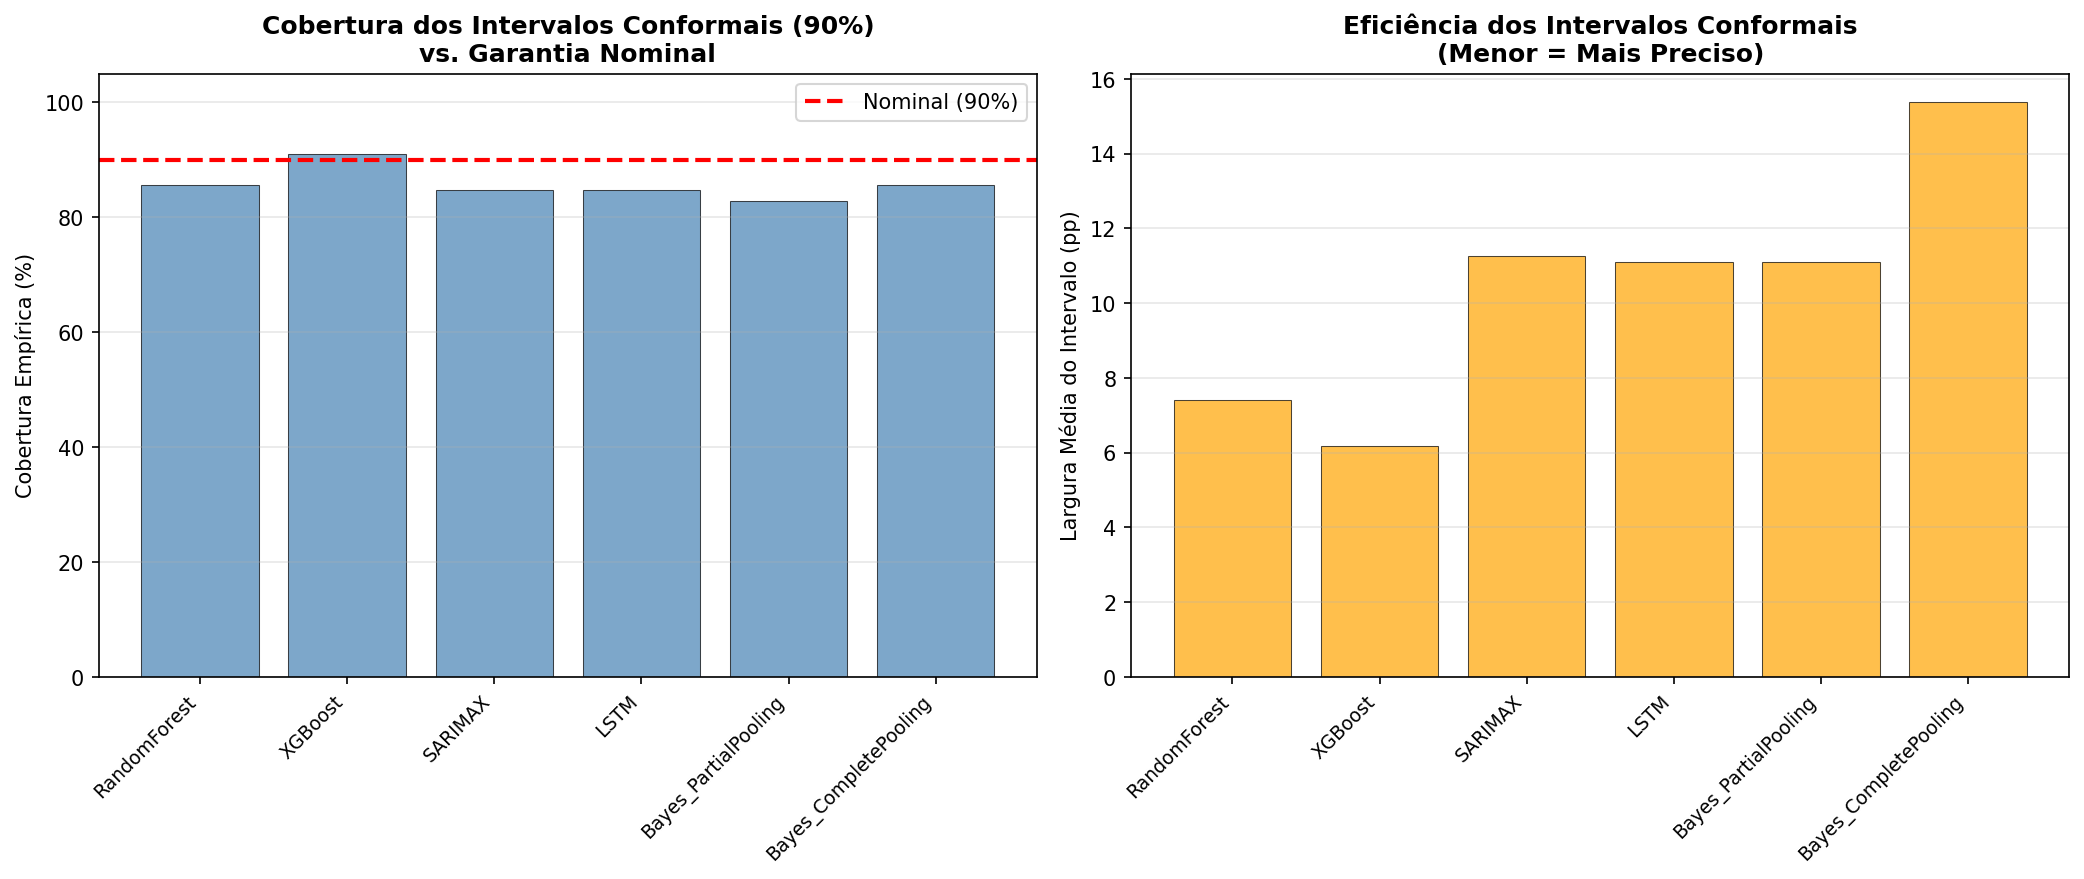


▶ conformal_fan_chart.png


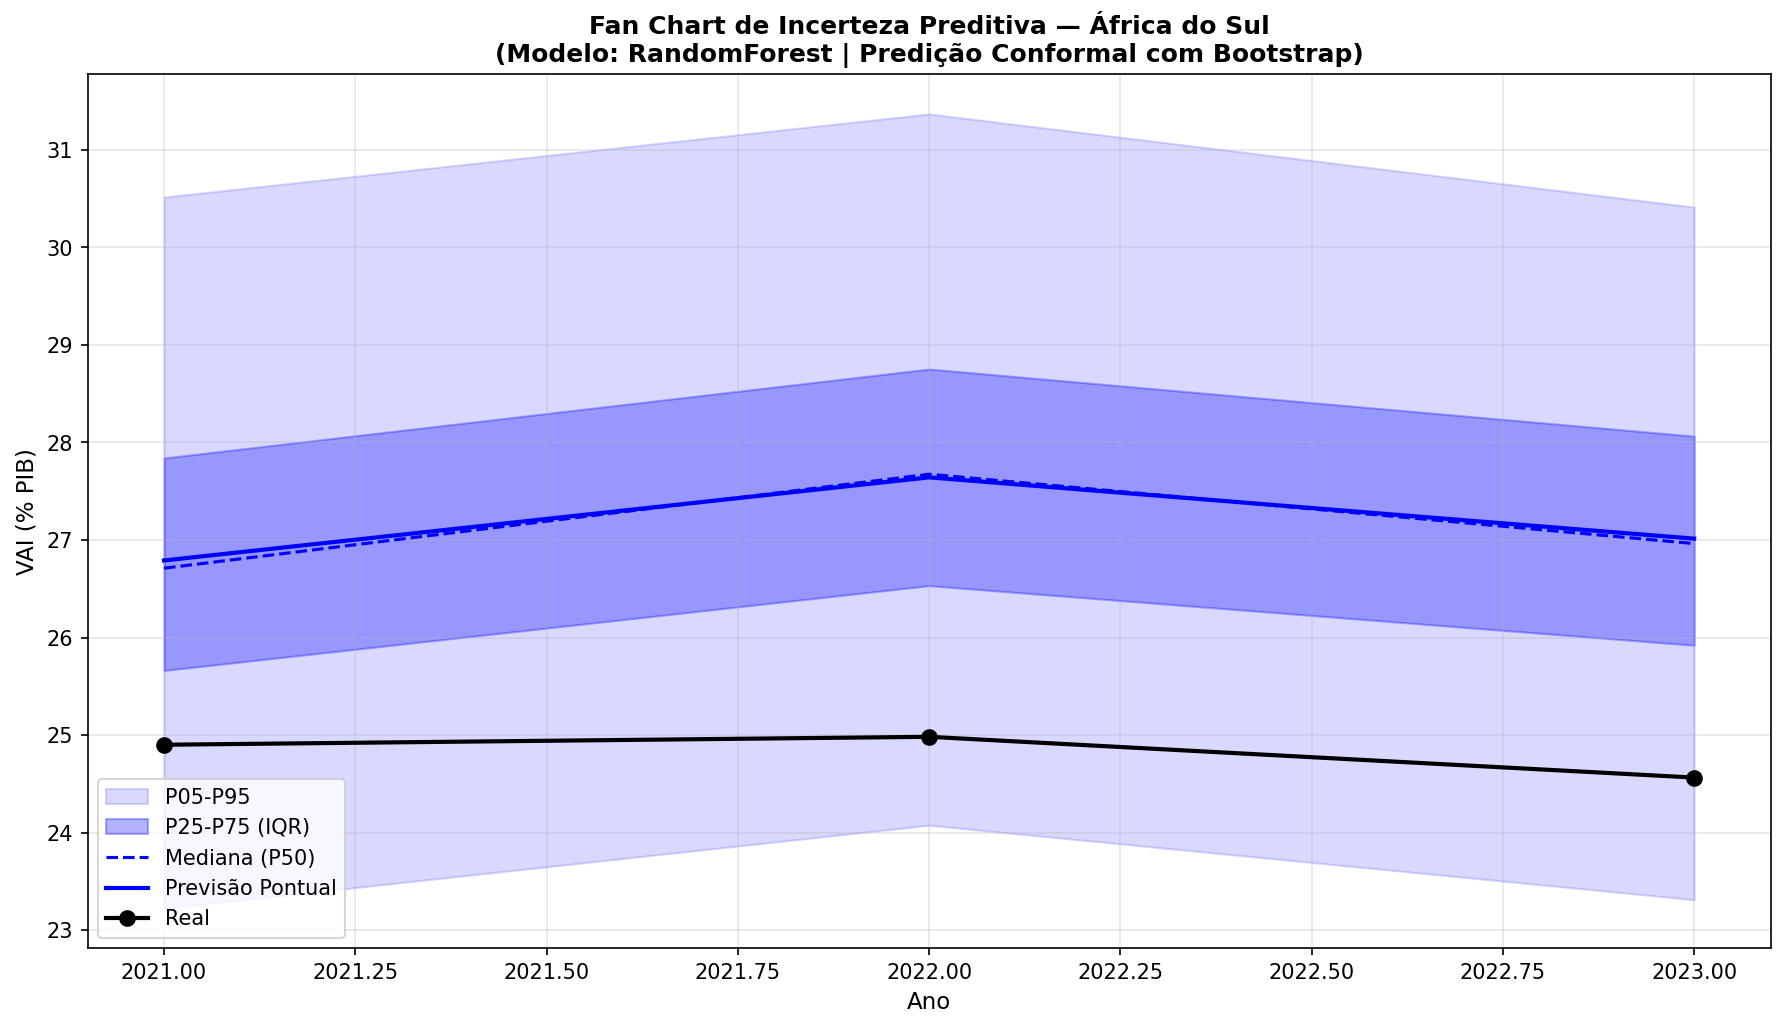


▶ conformal_incerteza_por_pais.png


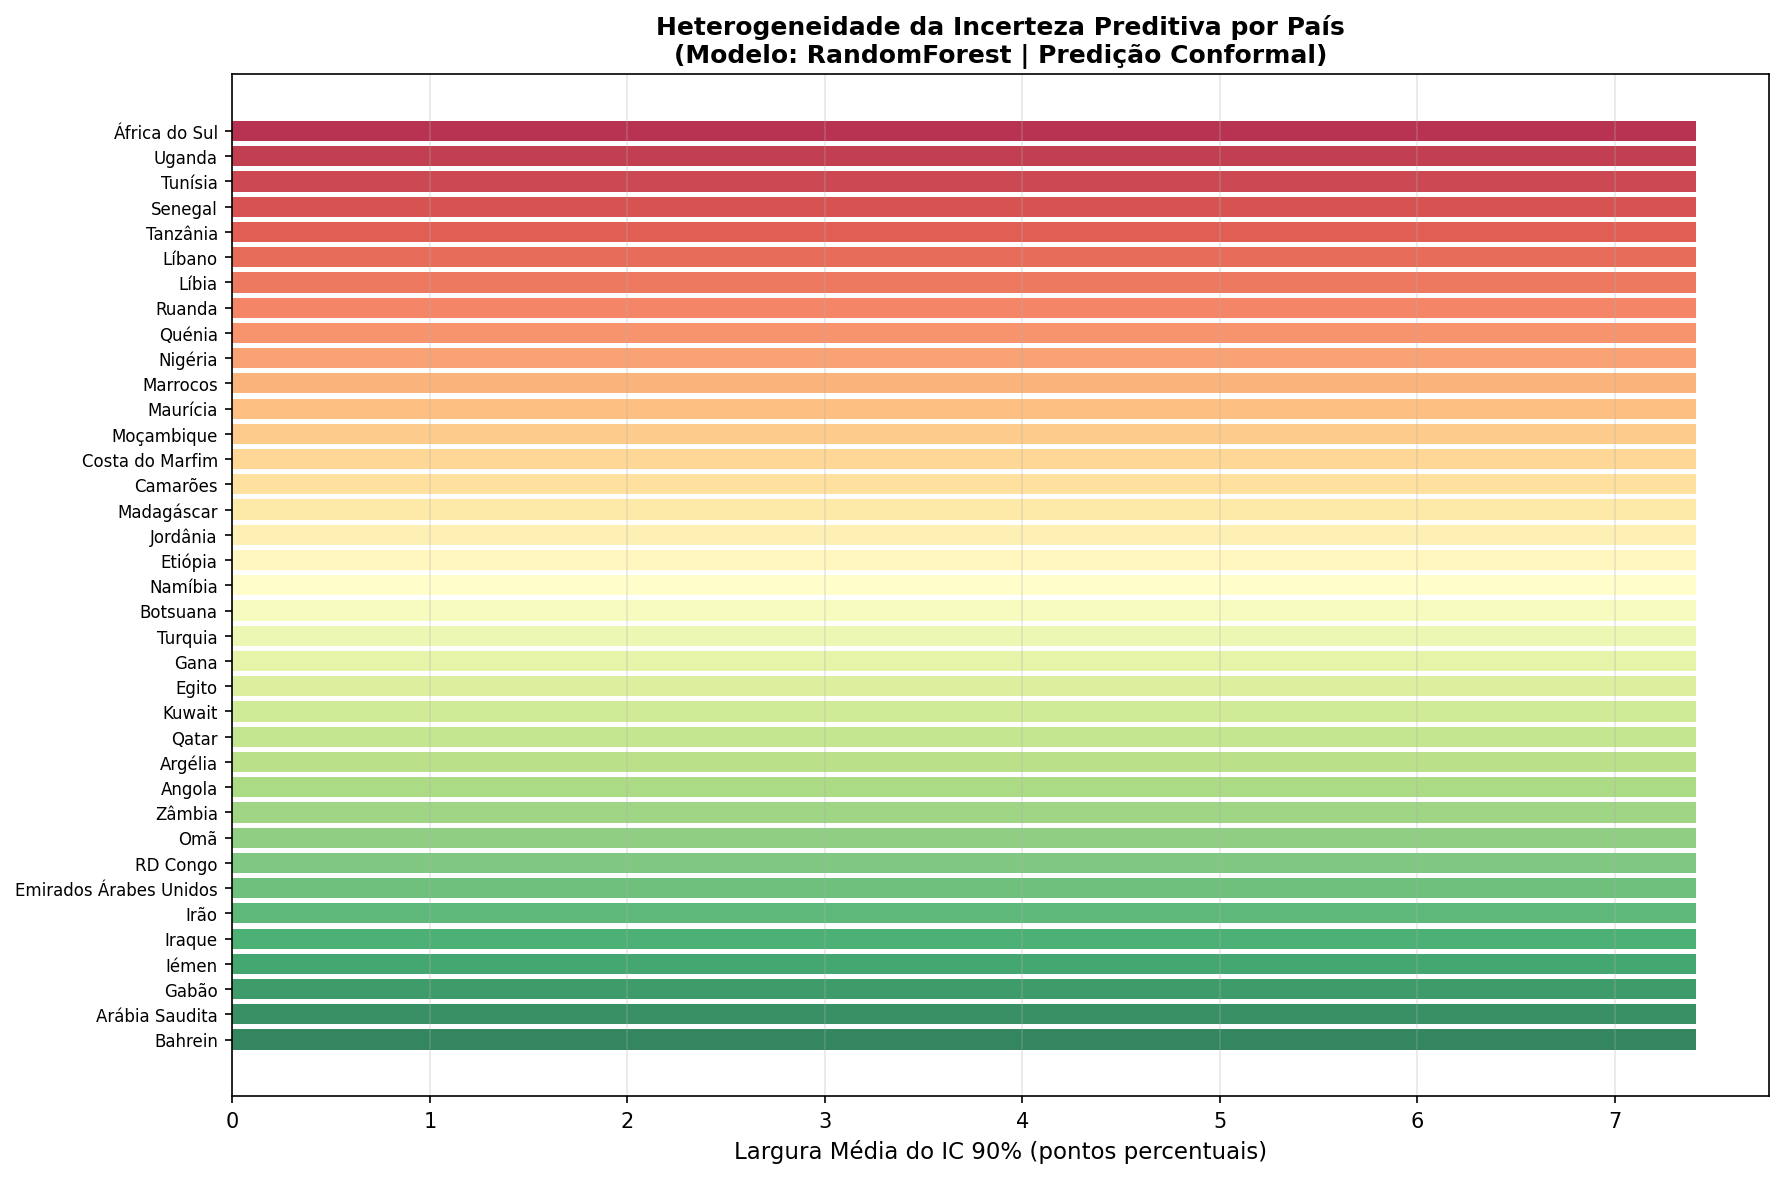


▶ conformal_intervalos_exemplo.png


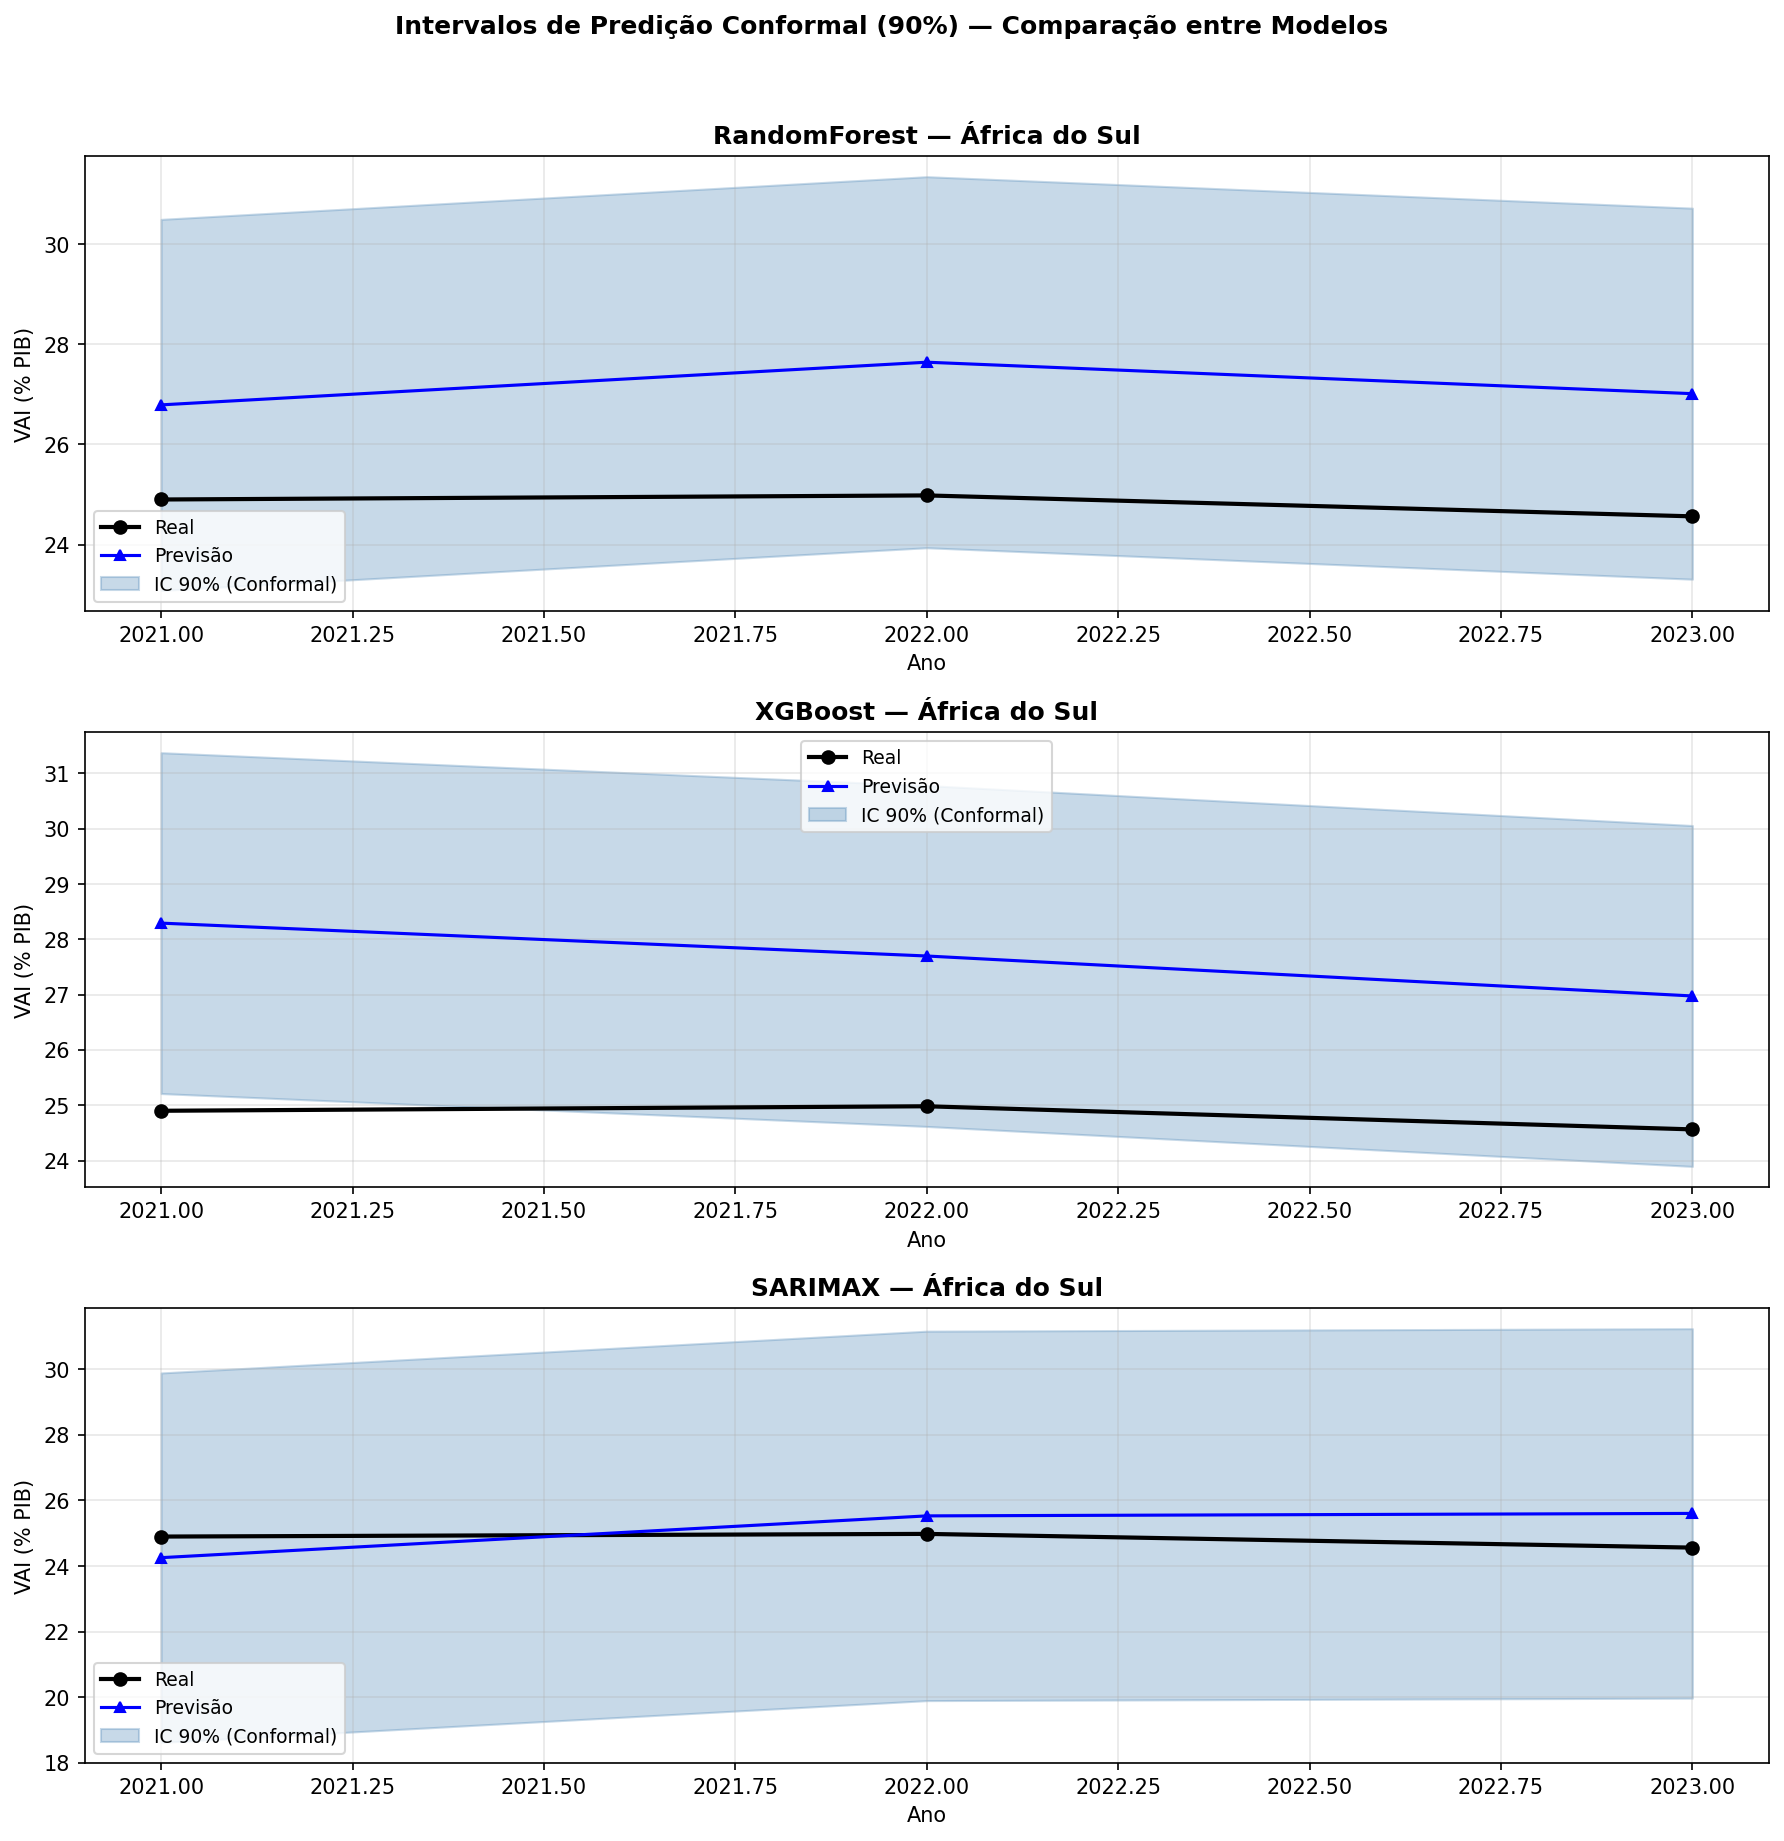


▶ contrafactual_dose_resposta.png


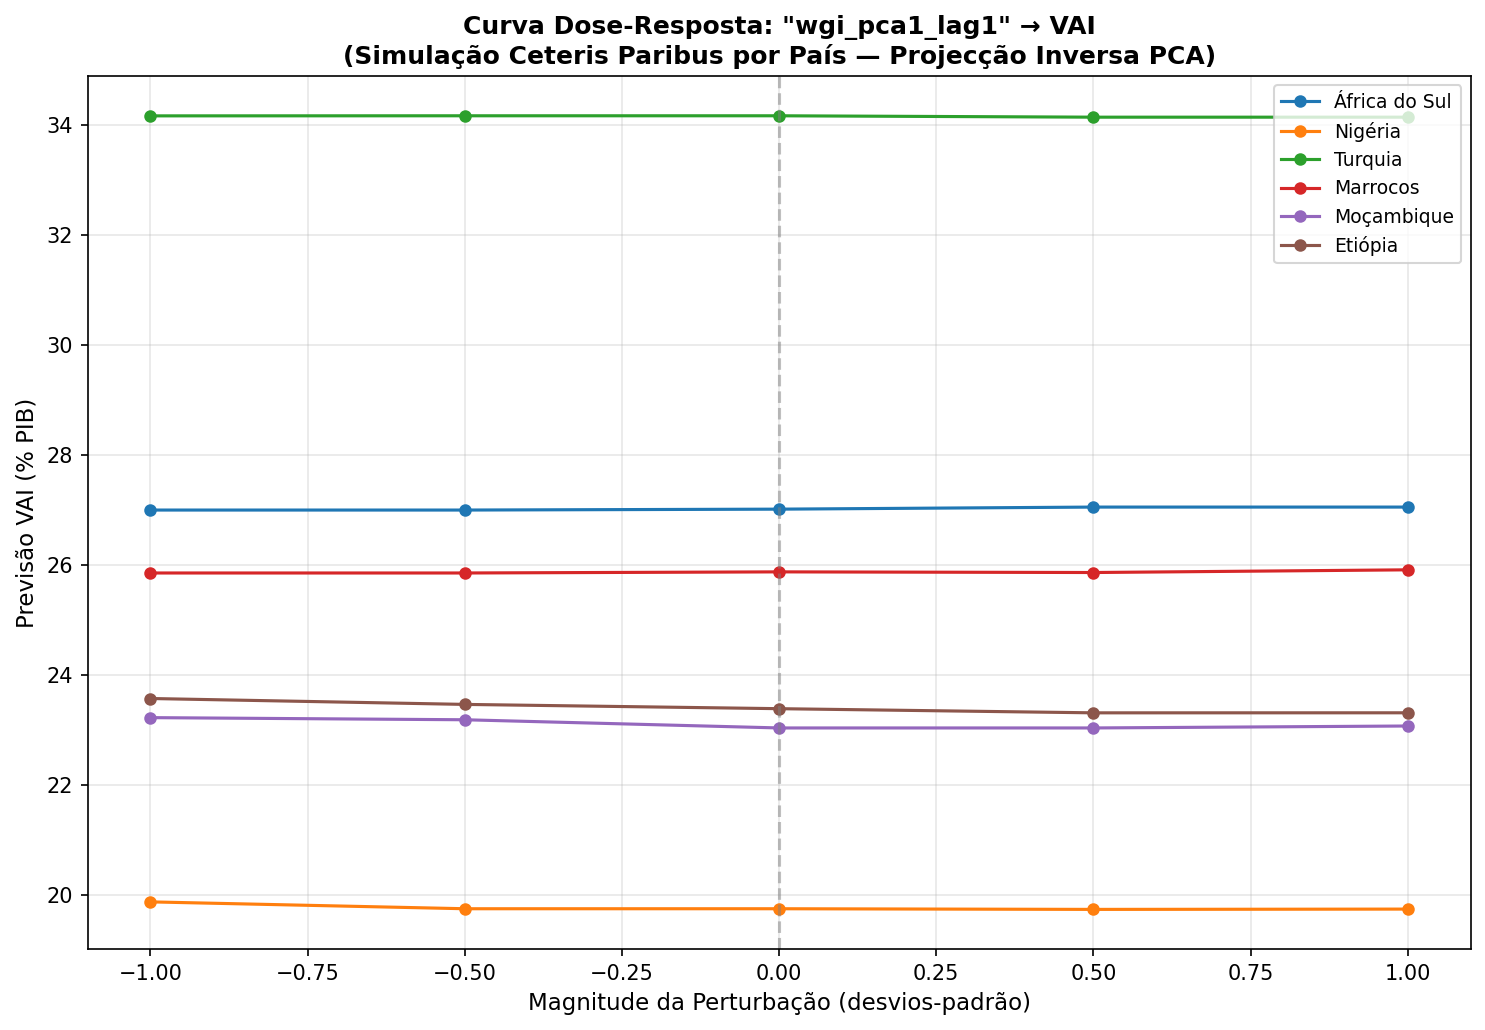


▶ contrafactual_impacto_pais.png


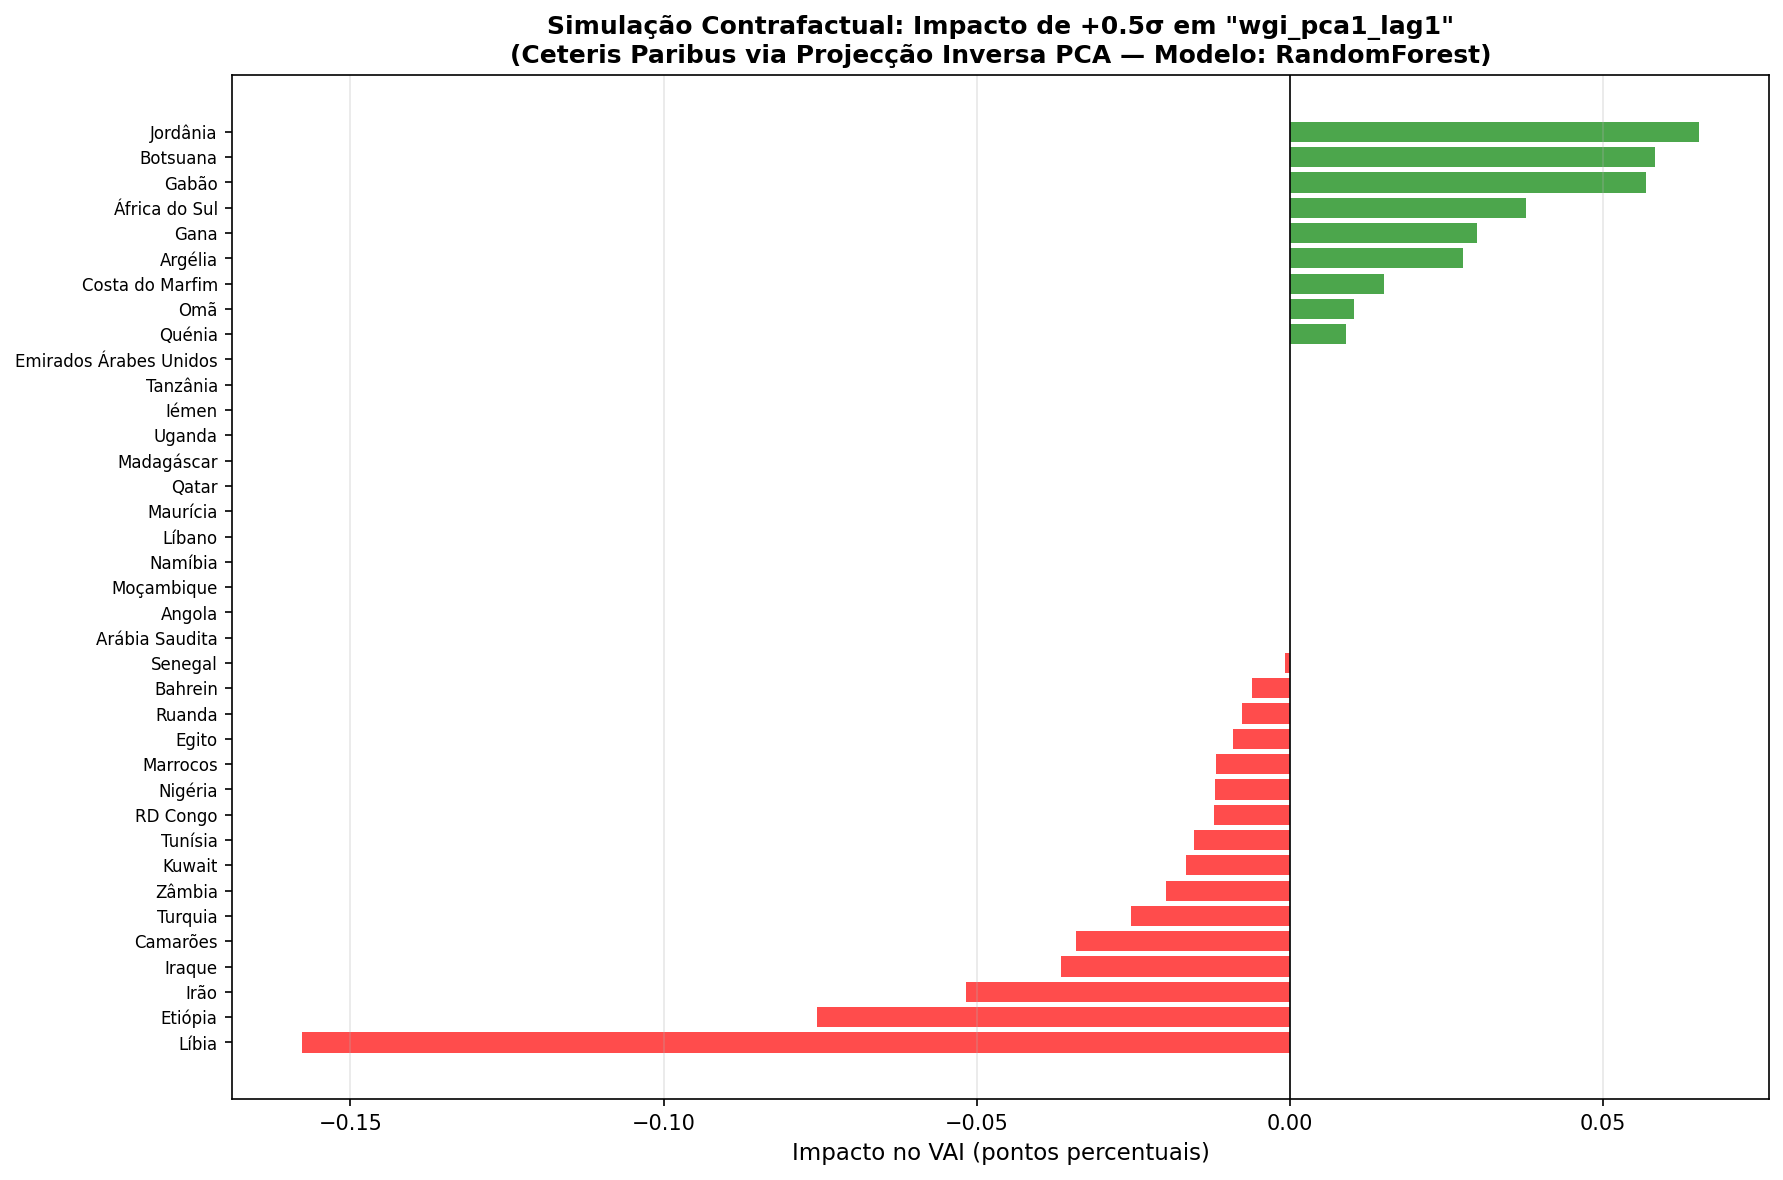


▶ contrafactual_shap_waterfall.png


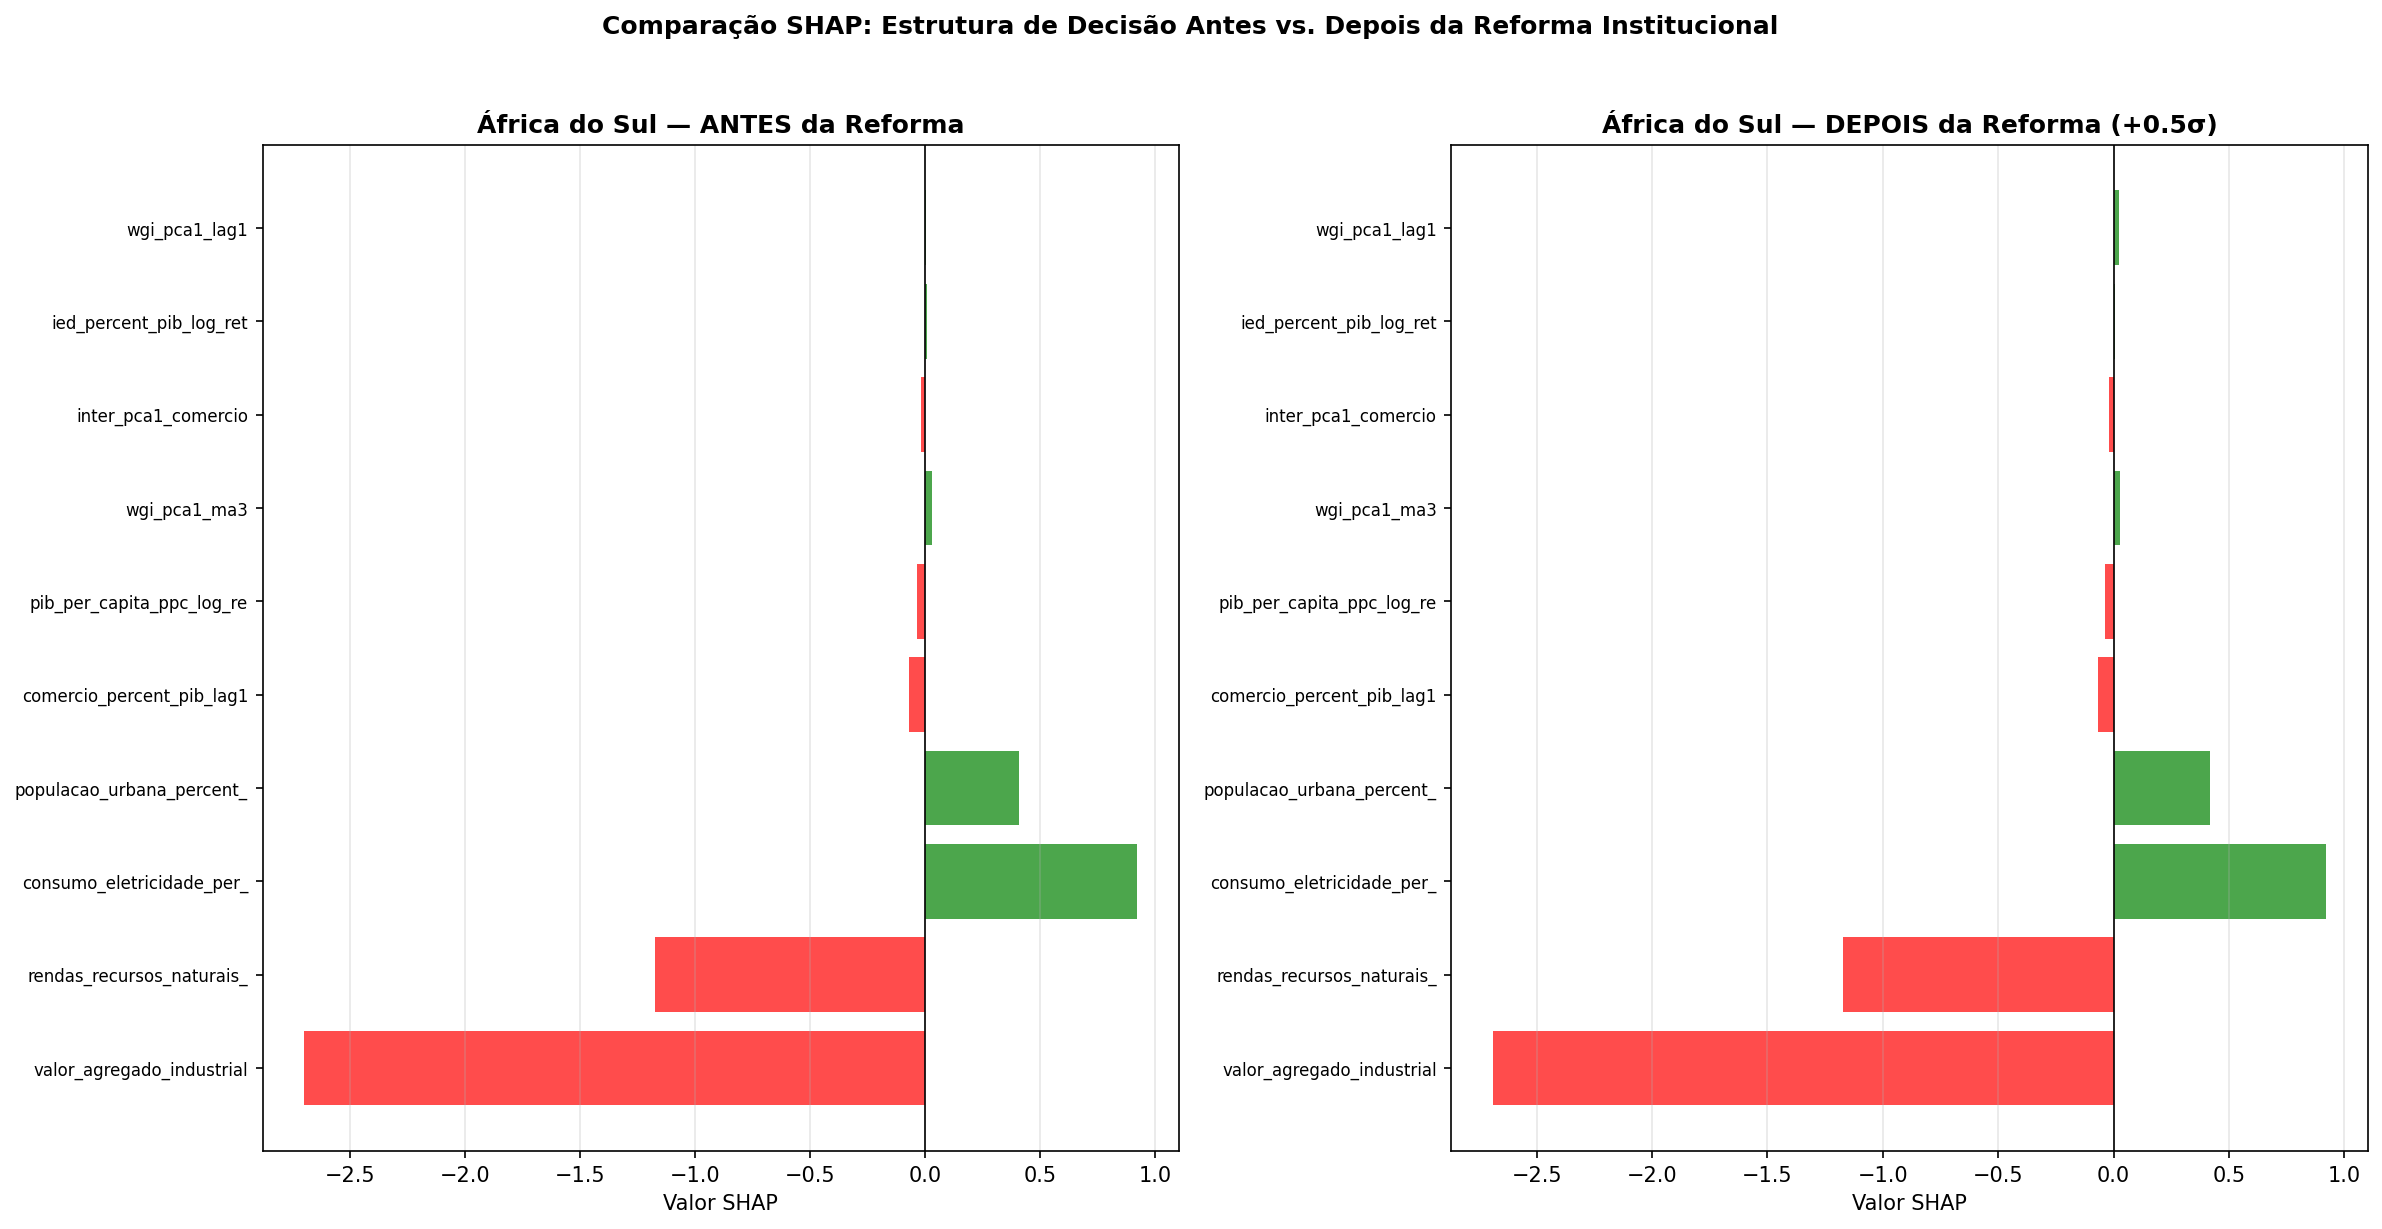


▶ quebras_exemplos_paises.png


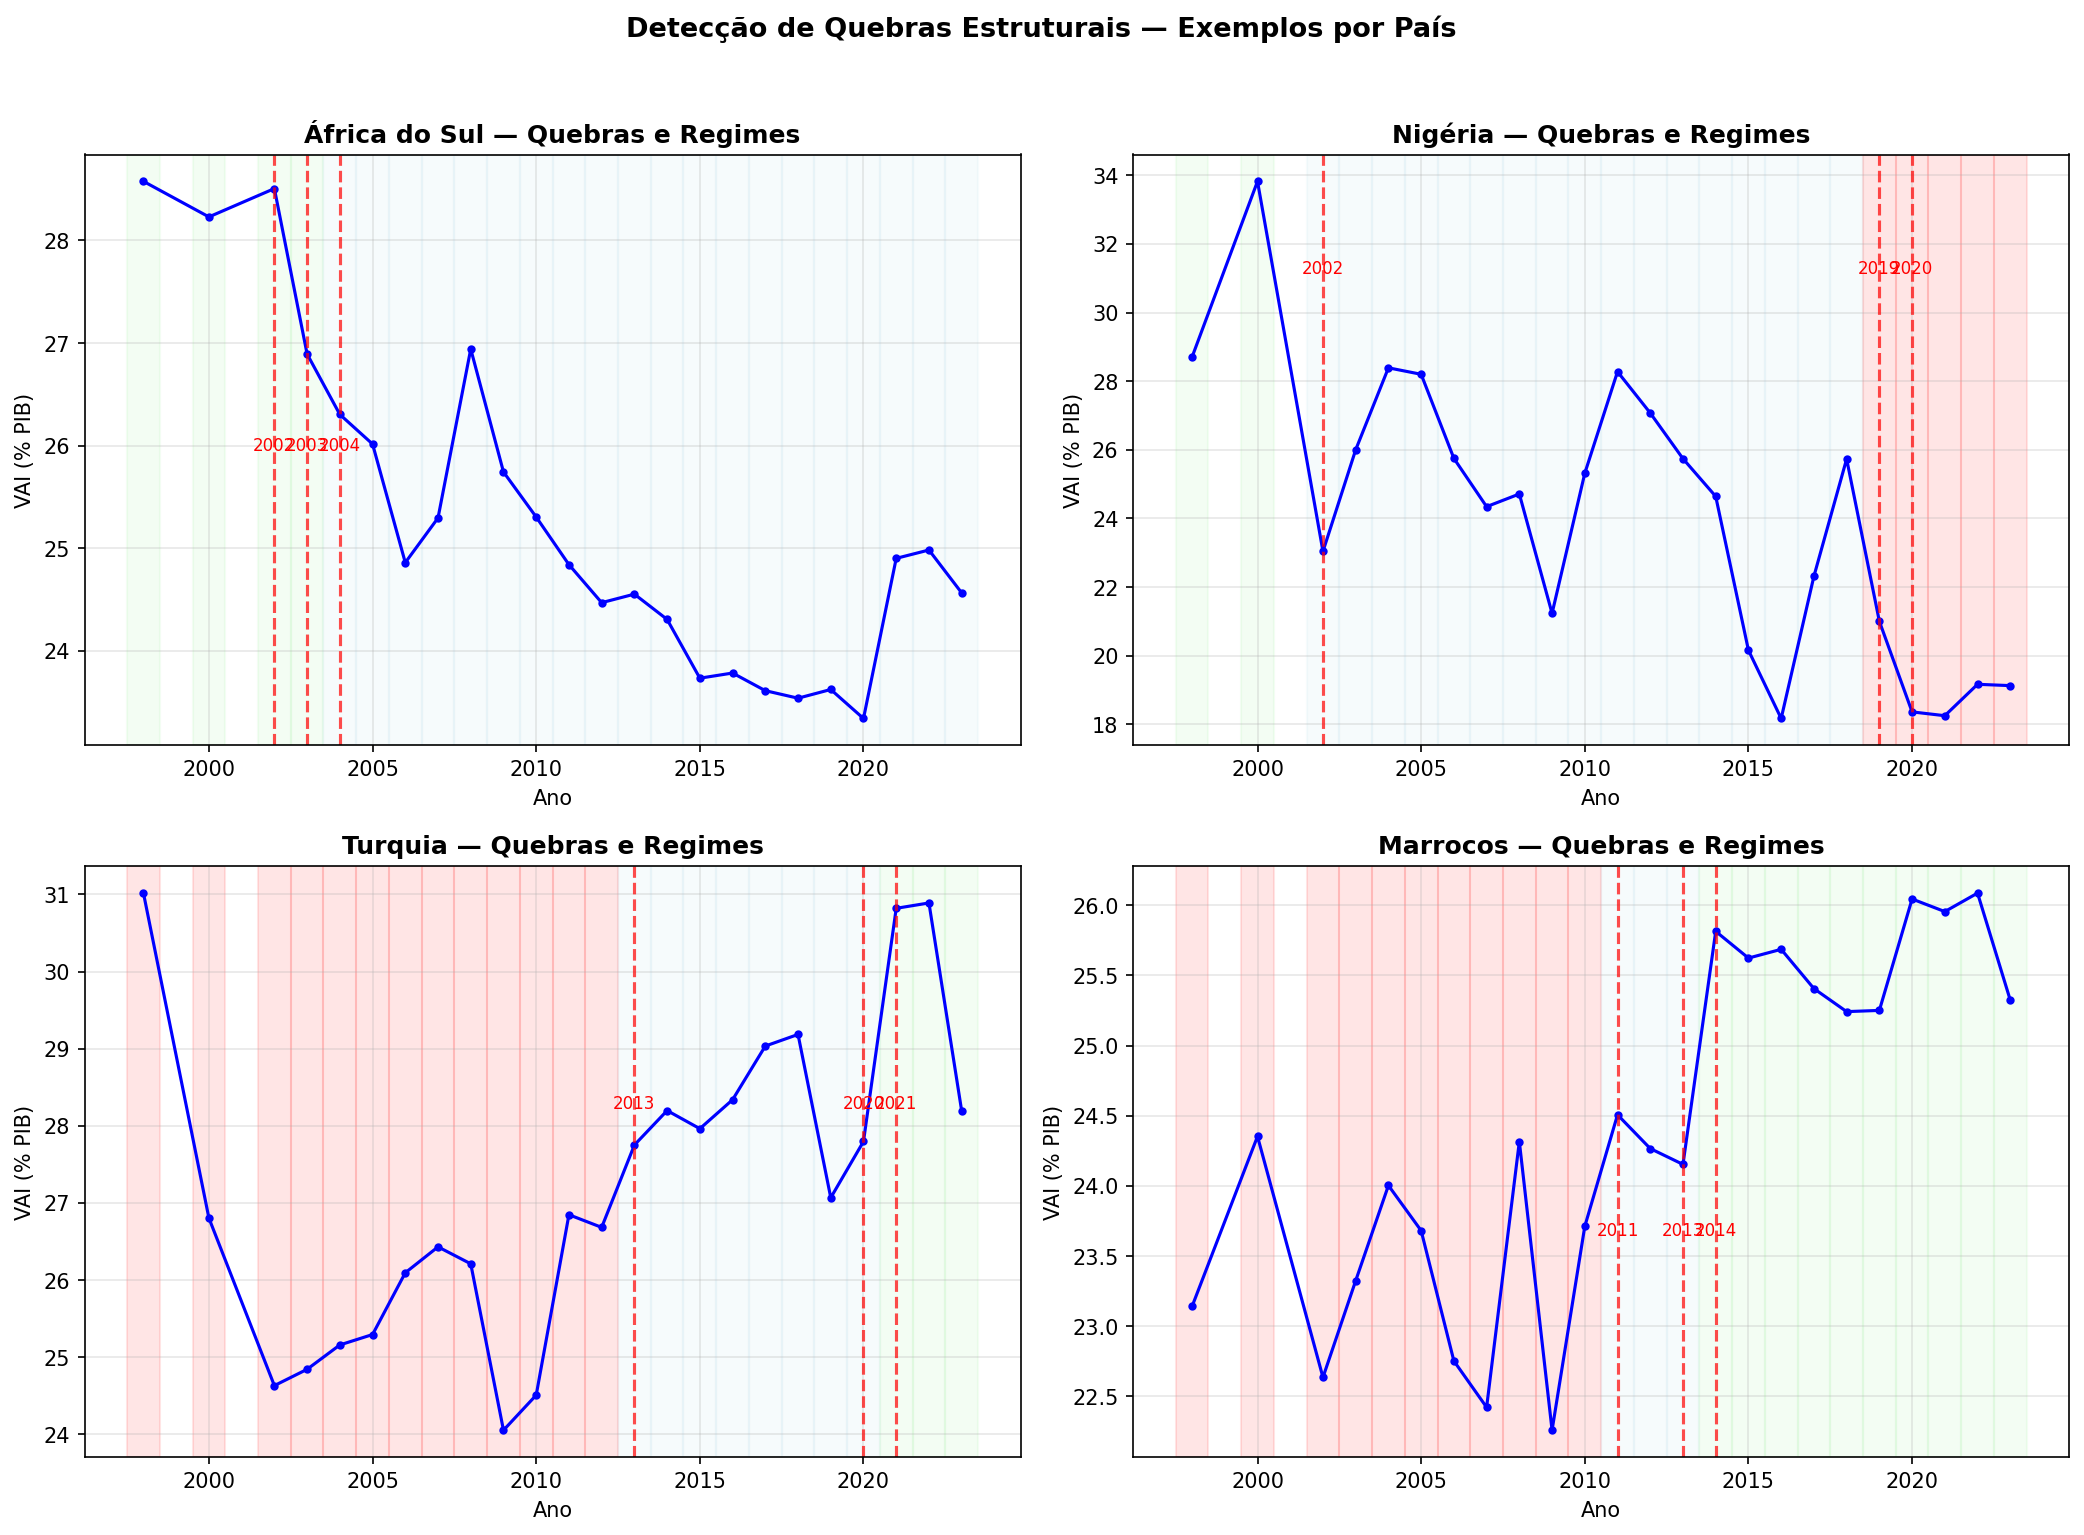


▶ quebras_timeline.png


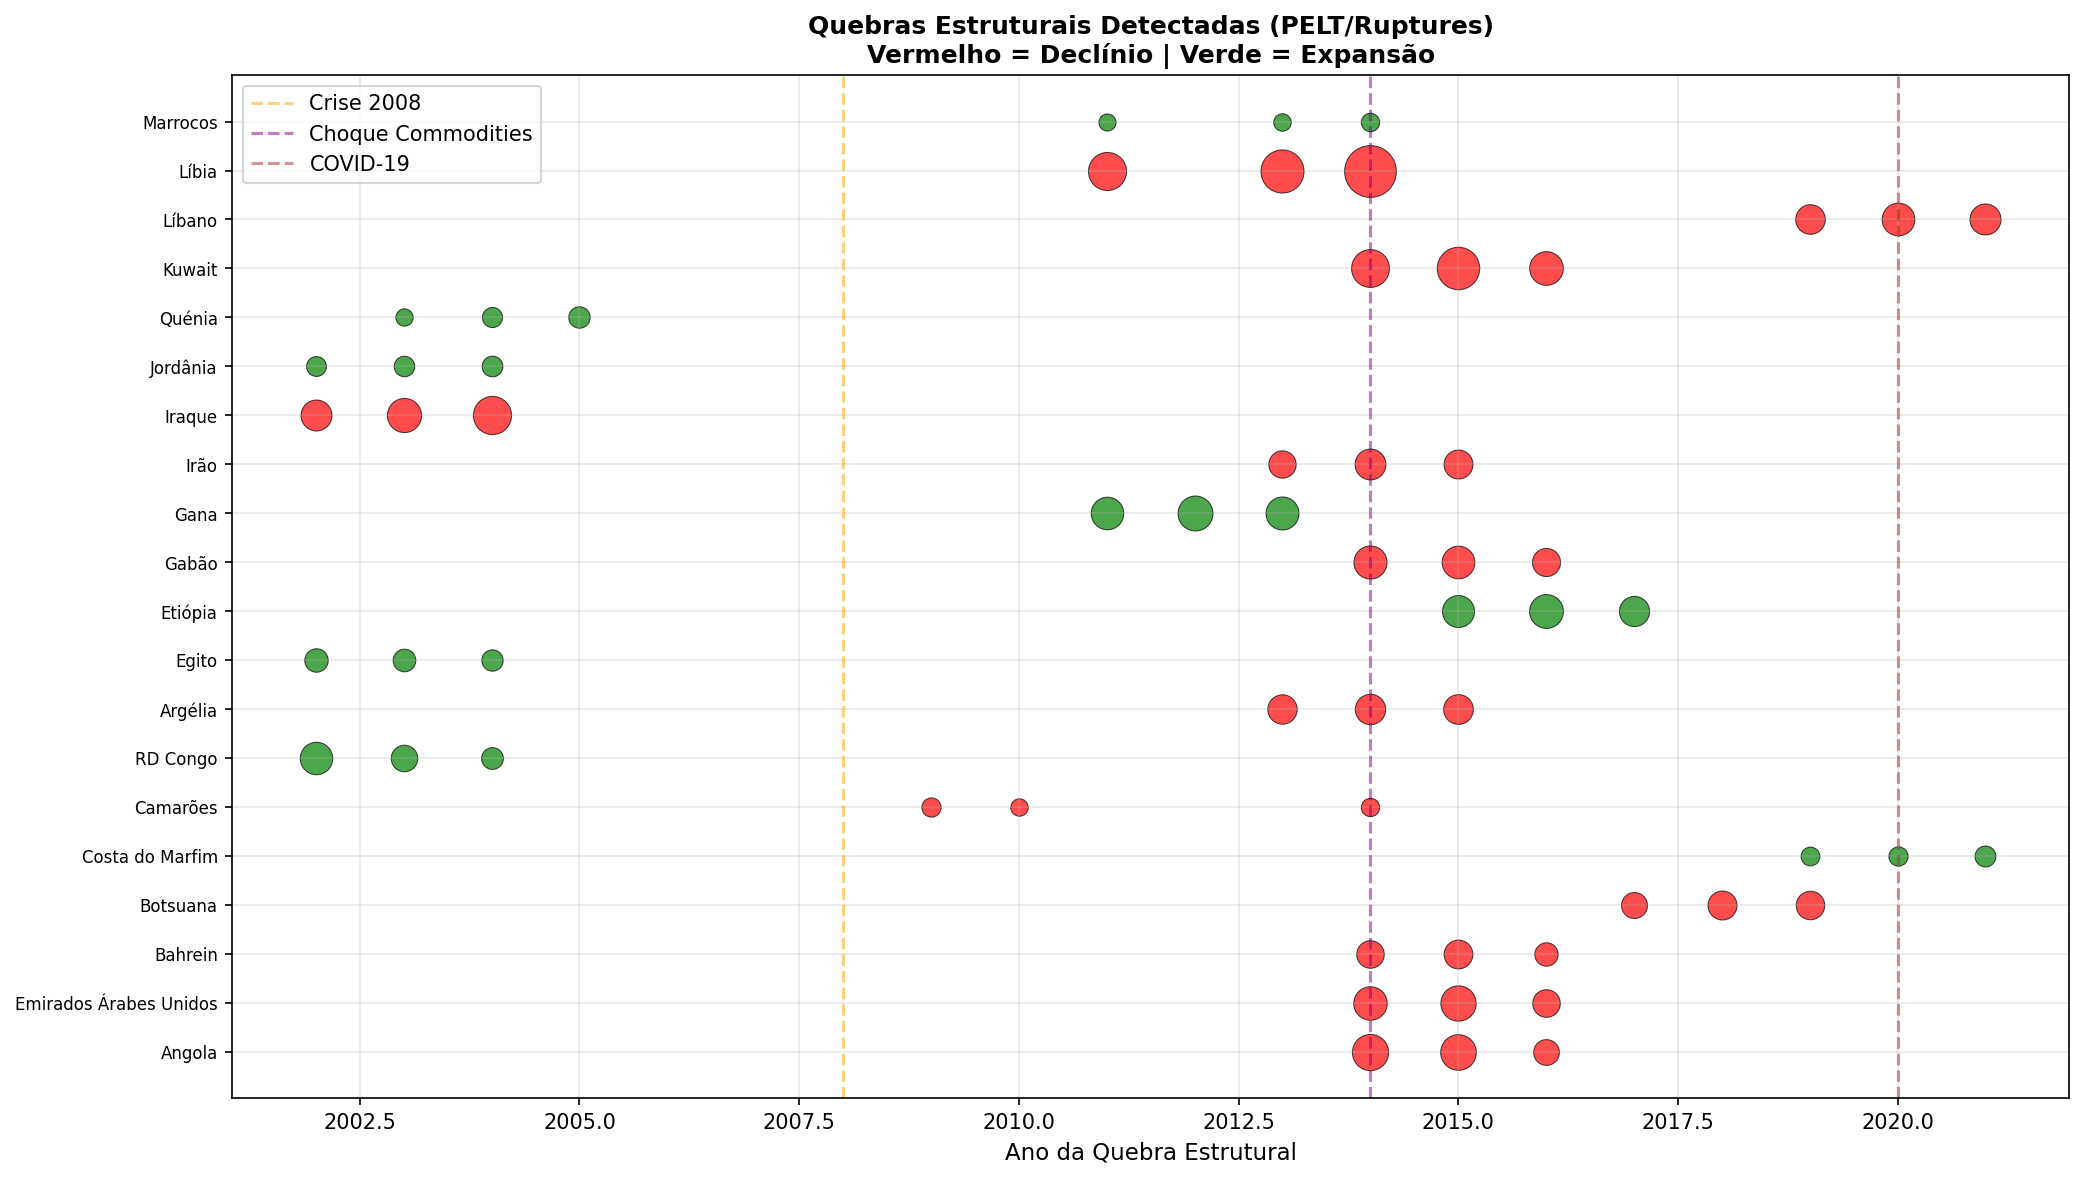


▶ regimes_temporal.png


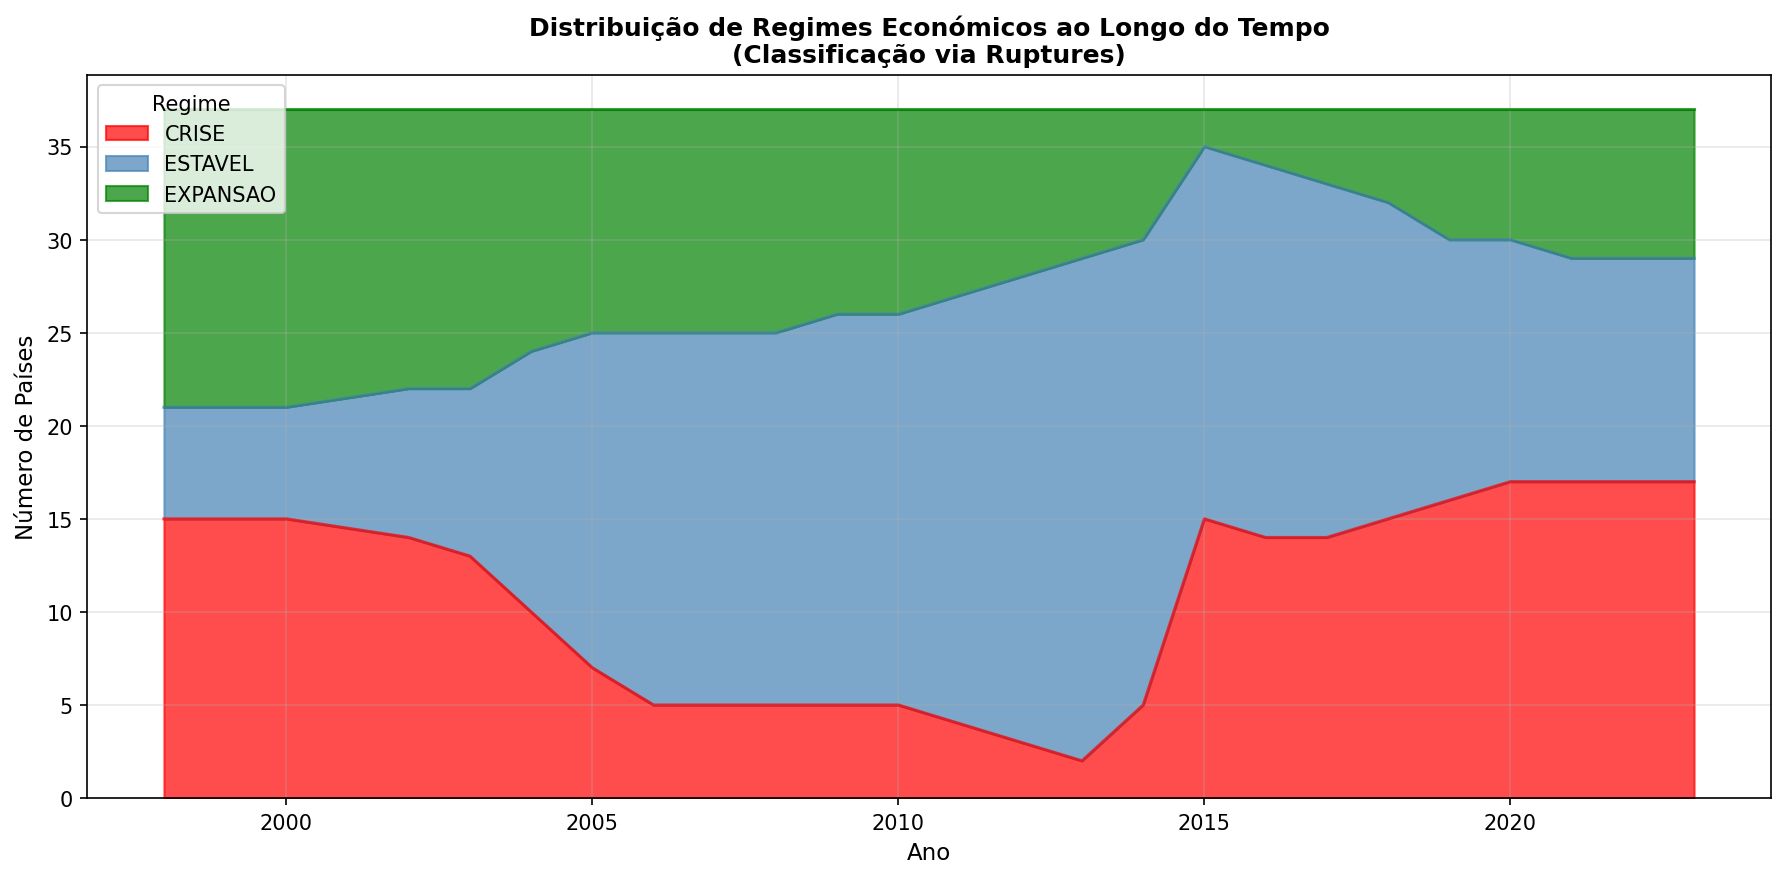

In [76]:
import os
from IPython.display import Image, display

# Pasta onde o Passo 10 guarda os ficheiros
PASTA = '/content/drive/MyDrive/inovacoes_mestrado'

print("📁 Conteúdo da pasta inovacoes_mestrado:")
for f in sorted(os.listdir(PASTA)):
    print(f"  - {f}")

print("\n" + "="*60)
print("🖼️ GRÁFICOS GERADOS")
print("="*60)

# Mostrar cada imagem PNG
for png in sorted([f for f in os.listdir(PASTA) if f.endswith('.png')]):
    print(f"\n▶ {png}")
    display(Image(filename=os.path.join(PASTA, png)))

**Baixar pastas de resultados**

In [ ]:
!zip -r repo.zip /content/repo

In [ ]:
from google.colab import files
files.download('repo.zip')